# Eigenstate–Fixed Point Correspondence

## An Investigation into the Connection Between Fixed-Point Dynamics and Quantum Eigenstates

**Author:** Keenan M Stone  
**Date started:** May 2017 (original scripts), April 2026 (this notebook)  
**Status:** Exploratory

---

## 1. Motivation and Background

### 1.1 The Core Intuition

The eigenvalue equation $\hat{A}|\psi\rangle = \lambda|\psi\rangle$ says: an operator acts on a state and returns *the same state* (up to scaling). In **projective Hilbert space** — where we identify $|\psi\rangle \sim c|\psi\rangle$ — this is exactly the definition of a **fixed point**. The eigenvalue $\lambda$ plays the role of $f'(x^*)$ at the fixed point, encoding its stability.

This suggests a dictionary:

| Fixed-point dynamics | Quantum eigenvalue problem |
|---|---|
| $f(x^*) = x^*$ | $\hat{A}|\psi\rangle = \lambda|\psi\rangle$ |
| $|f'(x^*)| < 1$: stable (attracting) | $|\lambda|$ largest: power method converges |
| $|f'(x^*)| > 1$: unstable (repelling) | $|\lambda|$ not largest: power method diverges |
| Alpha-transform $g = \alpha f + (1-\alpha)x$ | Relaxed iteration / spectral shift |
| Bifurcation in parameter $a$ | Spectral phase transitions as potential varies |

### 1.2 Why This Might Be More Than an Analogy

Several concrete algorithms already embody this connection without making it explicit:

- **Power iteration** converges to the eigenstate with largest $|\lambda|$ — the most "stable" fixed point of the projective map $|x\rangle \mapsto \hat{A}|x\rangle / \|\hat{A}|x\rangle\|$
- **Inverse power iteration with shift** $(\hat{A} - \sigma I)^{-1}$ converges to the eigenstate *nearest* $\sigma$ — this is fixed-point iteration with a *modified stability landscape*
- **Spectral shooting methods** find eigenvalues as zeros of a boundary mismatch — a *root-finding* problem that is itself a fixed-point problem

### 1.3 The Alpha-Transform (Original Work, 2017)

In the original Petrification scripts, an alpha-transform was used to convert unstable fixed points to stable ones:

$$g(x) = \alpha f(x) + (1-\alpha)x$$

The optimal $\alpha$ is computed from the extremal slope of $f$:
- If $f'_{\max} > 1$: $\alpha = \frac{2}{1 - f'_{\max}}$
- If $f'_{\min} < -1$: $\alpha = \frac{2}{1 - f'_{\min}}$

**Honest assessment:** This transform is relatively straightforward — it's a convex combination of $f$ with the identity that alters the derivative at fixed points: $g'(x^*) = \alpha f'(x^*) + (1-\alpha)$. Choosing $\alpha$ so that $|g'(x^*)| < 1$ is a direct application of Banach's contraction mapping theorem. A conjecture from earlier work (with colleagues) was that tuning $\alpha$ to the maximum *curvature* of $f$ could produce a global inversion of stability — turning all attractors into repulsors and vice versa — but this was never rigorously proved and may not hold generally.

The alpha-transform is unlikely to be novel in the numerical methods literature (it resembles successive over-relaxation, Anderson mixing, and Krasnoselskii-Mann iteration). Its value here is as a *bridge concept* connecting classical dynamical systems intuition to quantum spectral problems.

### 1.4 Turbiner's Nonlinearization — The Real Question

A.V. Turbiner showed that the substitution $\psi(x) = \exp\!\left(-\int^x y(t)\,dt\right)$ converts the linear Schrödinger equation

$$-\frac{\hbar^2}{2m}\psi'' + V(x)\psi = E\psi$$

into the nonlinear **Riccati-Bloch equation** (in natural units $\hbar = m = 1$):

$$y'(x) = y(x)^2 - 2V(x) + 2E$$

The eigenvalue $E$ is determined by the condition that $y(x)$ remains *regular* (no singularities). This gives a fixed-point characterization of eigenvalues: **they are the parameter values for which a nonlinear dynamical system has bounded trajectories.**

The more interesting questions are:
1. **Does this nonlinearization give us computational or analytical tools** that outperform existing methods for real problems?
2. **Is there a deeper structural connection between fixed points and eigenstates** that, once made explicit, opens new doors — either in quantum mechanics, or by applying quantum-like machinery to nonlinear/chaotic systems where it wasn't previously useful?
3. **Has this already been done?** If so, what did others find, and what was left unfinished?

### 1.5 What We're Really Looking For

The honest goal of this notebook is to investigate whether:
- Turbiner's Riccati-Bloch approach, combined with dynamical systems thinking, leads to **new algorithms** for eigenvalue problems that are faster or more accurate than standard methods (Numerov, DVR, complex scaling)
- The eigenstate–fixed-point correspondence leads to **new analytical results** — bounds, asymptotics, or structural theorems
- The connection can be **run in reverse**: applying quantum eigenvalue machinery to problems in nonlinear dynamics, chaos, or complex systems
- Any of this connects to **foundational questions**: interpretations of QM, emergence of quantization, or the structure of mathematical physics itself

There is a real chance none of these pan out. But we'll document what we find either way.

## 2. References

### Primary Sources

1. **Turbiner, A.V.** "The eigenvalue spectrum in quantum mechanics and the nonlinearization procedure." *Soviet Physics Uspekhi* 27.9 (1984): 668–694.  
   *Key result:* Riccati-Bloch nonlinearization; logarithmic substitution converts linear eigenvalue problems to nonlinear first-order ODEs.

2. **Turbiner, A.V.** "Quasi-exactly-solvable problems and sl(2) algebra." *Communications in Mathematical Physics* 118.3 (1988): 467–474.  
   *Key result:* Lie-algebraic approach to spectral problems; classification of quasi-exactly-solvable potentials.

3. **Turbiner, A.V.** "One-dimensional quasi-exactly solvable Schrödinger equations." *Physics Reports* 642 (2016): 1–71.  
   *Key result:* Comprehensive review of QES methods and nonlinearization.

### Textbooks and Background

4. **Strogatz, S.H.** *Nonlinear Dynamics and Chaos.* 2nd ed., CRC Press, 2015.  
   *Chapters 2, 10:* Fixed-point classification, bifurcation theory, logistic map.

5. **Griffiths, D.J. and Schroeter, D.F.** *Introduction to Quantum Mechanics.* 3rd ed., Cambridge University Press, 2018.  
   *Chapter 2:* Time-independent Schrödinger equation; eigenvalue problems for standard potentials.

6. **Trefethen, L.N. and Bau, D.** *Numerical Linear Algebra.* SIAM, 1997.  
   *Chapters 25–27:* Power iteration, inverse iteration, QR algorithm — all castable as fixed-point methods.

7. **Reid, W.T.** *Riccati Differential Equations.* Academic Press, 1972.  
   *Chapters 1–3:* Theory of the Riccati equation; connection to linear second-order ODEs.

### Fixed-Point Theory in Quantum Mechanics

8. **Wilson, K.G.** "The renormalization group: Critical phenomena and the Kondo problem." *Reviews of Modern Physics* 47.4 (1975): 773.  
   *Key result:* Renormalization group as iterated map; critical exponents from fixed-point analysis.

9. **Kadanoff, L.P.** "Scaling laws for Ising models near $T_c$." *Physics Physique Fizika* 2.6 (1966): 263.  
   *Key result:* Block-spin RG as discrete map with fixed points corresponding to phase transitions.

10. **Migdal, A.A.** "Recursion equations in gauge theories." *Soviet Physics JETP* 42.3 (1975): 413.  
    *Key result:* Migdal-Kadanoff approximation relating lattice gauge theory to iterated maps.

### Koopman Operator Theory and Transfer Operators

11. **Koopman, B.O.** "Hamiltonian systems and transformation in Hilbert space." *Proceedings of the National Academy of Sciences* 17.5 (1931): 315–318.  
    *Key result:* Linear operator acting on observables of nonlinear dynamical systems; spectral decomposition of nonlinear dynamics.

12. **Mezić, I.** "Spectral properties of dynamical systems, model reduction and decompositions." *Nonlinear Dynamics* 41 (2005): 309–325.  
    *Key result:* Modern Koopman spectral analysis; eigenvalues encode dynamics of nonlinear systems in a linear framework.

13. **Budišić, M., Mohr, R., and Mezić, I.** "Applied Koopmanism." *Chaos* 22.4 (2012): 047510.  
    *Key result:* Computational methods for Koopman eigenfunctions; connections to DMD (Dynamic Mode Decomposition).

14. **Brunton, S.L. and Kutz, J.N.** *Data-Driven Science and Engineering.* 2nd ed., Cambridge University Press, 2022.  
    *Chapters 7–8:* DMD and Koopman analysis as data-driven spectral methods for nonlinear systems.

15. **Ruelle, D.** "Zeta-functions for expanding maps and Anosov flows." *Inventiones Mathematicae* 34 (1976): 231–242.  
    *Key result:* Dynamical zeta functions; spectral properties of transfer operators encode statistical mechanics of chaotic systems.

### Nonlinear Eigenvalue Problems and Relaxation

16. **Güttel, S. and Tisseur, F.** "The nonlinear eigenvalue problem." *Acta Numerica* 26 (2017): 1–94.  
    *Key result:* Comprehensive survey of nonlinear eigenvalue problems; algorithms including Newton-type, contour integral, and linearization methods.

17. **Krasnoselskii, M.A.** "Two remarks on the method of successive approximations." *Uspekhi Matematicheskikh Nauk* 10.1 (1955): 123–127.  
    *Key result:* Krasnoselskii-Mann iteration — averaged fixed-point iteration. The alpha-transform is an instance of this general technique.

18. **Fröman, N. and Fröman, P.O.** *Physical Problems Solved by the Phase-Integral Method.* Cambridge University Press, 2002.  
    *Key result:* JWKB/phase-integral methods as Riccati-based approaches to Schrödinger eigenvalue problems — closely related to Turbiner's nonlinearization.

### This Project

19. **Stone, K.M.** "Petrification scripts." (2017, unpublished).  
    *Alpha-transform for stabilizing unstable fixed points of the logistic and Migdal-Kadanoff maps.*

20. **Stone, K.M.** "Nullified: Self-Containment Nullification applied to QED." (2025–2026, unpublished).  
    *Set-theoretic axiom applied to Feynman diagram filtering; falsified at 415σ but infrastructure reusable.*

## 3. Setup and Imports

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# Petrification modules
from petrification.maps import logistic, migdal_kadanoff
from petrification.transforms import alpha_transform, compute_optimal_alpha
from petrification.bifurcation import compute_bifurcation, compute_bifurcation_transformed
from petrification.potentials import harmonic, anharmonic, double_well, morse
from petrification.quantum import (
    discretize_hamiltonian, solve_eigenstates,
    riccati_solve, riccati_alpha, spectral_scan, detect_eigenvalues,
    inverse_power_iteration, projective_power_iteration, alpha_eigenstate_scan,
)
from petrification.iteration import iterate, iterate_transformed, cobweb_data, find_fixed_points

%matplotlib inline
plt.rcParams.update({'figure.figsize': (12, 8), 'font.size': 12})
print('All imports successful.')

All imports successful.


## 4. Part I — Fixed-Point Analysis of Discrete Maps (Review)

Before bridging to quantum mechanics, we establish the fixed-point toolkit using classical discrete dynamical systems. This section reviews and generalizes the original 2017 Petrification scripts.

### 4.1 Cobweb Diagrams and the Alpha-Transform

For the logistic map $f(x) = ax(1-x)$ at $a = 4.0$, the fixed point at $x^* = 1 - 1/a = 0.75$ is **unstable** ($|f'(x^*)| = |2 - a| = 2 > 1$). The alpha-transform stabilizes it.

Optimal alpha = -0.3333
  Method: max, df_max = 4.0, df_min = -4.0


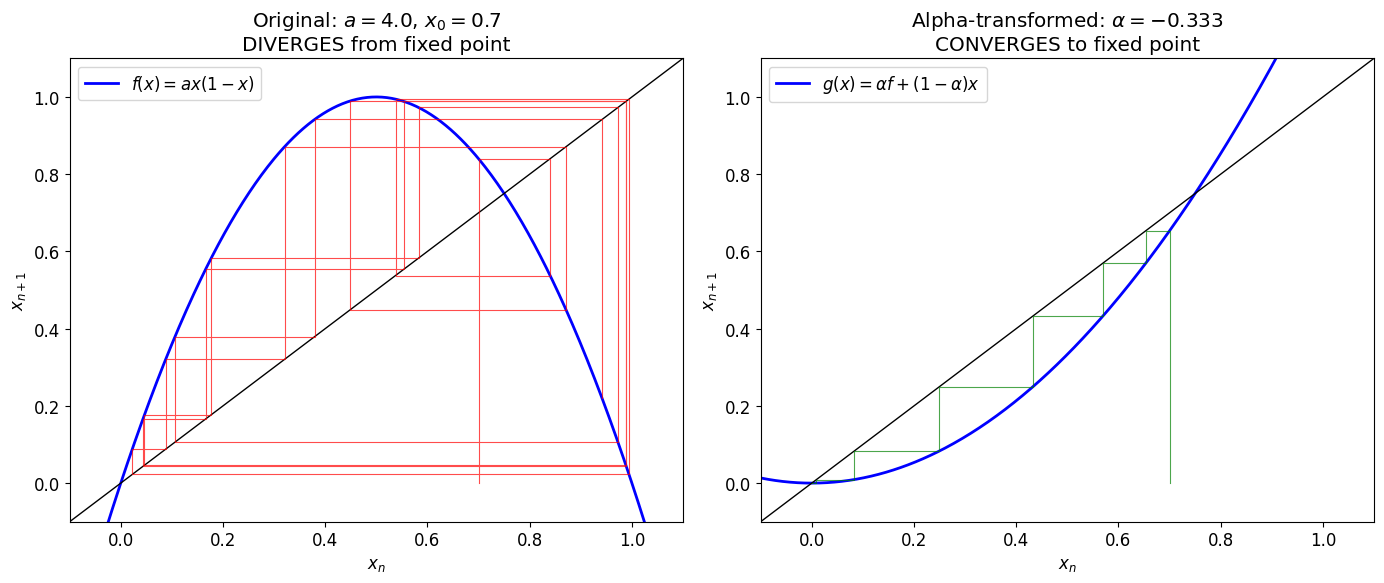

In [2]:
a = 4.0
x0 = 0.7

# Compute optimal alpha (restrict domain to [0,1] for logistic map)
alpha, info = compute_optimal_alpha(logistic, a, x_domain=(0.0, 1.0))
print(f"Optimal alpha = {alpha:.4f}")
print(f"  Method: {info['method']}, df_max = {info['df_max']}, df_min = {info['df_min']}")

# Cobweb data
Ix_orig, Iy_orig = cobweb_data(logistic, a, x0, n_iter=20)
Ix_trans, Iy_trans = cobweb_data(logistic, a, x0, n_iter=20, alpha=alpha)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
lx = np.linspace(-0.1, 1.1, 500)

# Original
ax1.plot(lx, logistic(a, lx), 'b-', lw=2, label=r'$f(x) = ax(1-x)$')
ax1.plot(lx, lx, 'k-', lw=1)
ax1.plot(Ix_orig, Iy_orig, 'r-', lw=0.8, alpha=0.7)
ax1.set_xlabel(r'$x_n$')
ax1.set_ylabel(r'$x_{n+1}$')
ax1.set_title(f'Original: $a={a}$, $x_0={x0}$\nDIVERGES from fixed point')
ax1.set_xlim(-0.1, 1.1)
ax1.set_ylim(-0.1, 1.1)
ax1.legend()

# Transformed
ly_t = alpha * logistic(a, lx) + (1 - alpha) * lx
ax2.plot(lx, ly_t, 'b-', lw=2, label=rf'$g(x) = \alpha f + (1-\alpha)x$')
ax2.plot(lx, lx, 'k-', lw=1)
ax2.plot(Ix_trans, Iy_trans, 'g-', lw=0.8, alpha=0.7)
ax2.set_xlabel(r'$x_n$')
ax2.set_ylabel(r'$x_{n+1}$')
ax2.set_title(rf'Alpha-transformed: $\alpha={alpha:.3f}$' + '\nCONVERGES to fixed point')
ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.legend()

plt.tight_layout()
plt.show()

### 4.2 Stability Theory of the Alpha-Transform

We now derive the exact conditions under which the alpha-transform reverses fixed-point stability and determine the optimal value of $\alpha$.

**Setup.** Let $f: \mathbb{R} \to \mathbb{R}$ be a $C^1$ map with fixed points $\{x_i^*\}$ where $f(x_i^*) = x_i^*$. Define
$$g(x) = \alpha f(x) + (1 - \alpha) x$$
Since $f(x_i^*) = x_i^*$, we have $g(x_i^*) = \alpha x_i^* + (1-\alpha) x_i^* = x_i^*$, so **$g$ has exactly the same fixed points as $f$** for any $\alpha$.

**Proposition 1 (Transformed slope).** At any fixed point $x^*$, the slope of $g$ is:
$$g'(x^*) = \alpha f'(x^*) + (1 - \alpha) = 1 + \alpha\bigl(f'(x^*) - 1\bigr)$$

*Proof.* Direct differentiation: $g'(x) = \alpha f'(x) + (1 - \alpha)$. Evaluate at $x = x^*$. $\square$

Writing $\lambda = f'(x^*)$, the transformed slope is $g'(x^*) = 1 + \alpha(\lambda - 1)$.

**Proposition 2 (Stability interval).** The fixed point $x^*$ is stable under $g$ (i.e., $|g'(x^*)| < 1$) if and only if:
$$-\frac{2}{\lambda - 1} < \alpha < 0 \quad \text{when } \lambda > 1$$
$$0 < \alpha < \frac{2}{1 - \lambda} \quad \text{when } \lambda < -1$$
$$\alpha \in (0, 1) \cup (1, \infty) \text{ or } (-\infty, 0) \quad \text{when } |\lambda| < 1 \text{ (already stable at } \alpha=1\text{)}$$

*Proof.* We need $|1 + \alpha(\lambda-1)| < 1$. Expanding:
$$-1 < 1 + \alpha(\lambda - 1) < 1$$
$$-2 < \alpha(\lambda - 1) < 0$$
When $\lambda > 1$: $\lambda - 1 > 0$, so $-2/(\lambda-1) < \alpha < 0$.  
When $\lambda < -1$: $\lambda - 1 < 0$, dividing reverses inequalities, giving $0 < \alpha < 2/(1-\lambda)$. $\square$

**Proposition 3 (Optimal alpha).** The value $\alpha^* = 1/(1 - \lambda)$ **zeroes the transformed slope** ($g'(x^*) = 0$), giving the fastest possible local convergence.

*Proof.* $g'(x^*) = 1 + \alpha(\lambda - 1) = 1 + \frac{\lambda - 1}{1 - \lambda} = 1 - 1 = 0$. $\square$

Note: $\alpha^*$ is the midpoint of the stability interval $\bigl(-2/(\lambda-1),\, 0\bigr)$ or $\bigl(0,\, 2/(1-\lambda)\bigr)$.

**Remark (Current code).** The `compute_optimal_alpha` function and the original 2017 `globify` use $\alpha = 2/(1 - \lambda_{\max})$, which is the **boundary** of the stability interval — the point where $g'(x^*) = -1$. At this boundary, iterations enter a period-2 oscillation around the fixed point rather than converging monotonically. The truly optimal value is $\alpha^* = 1/(1-\lambda_{\max})$, which is half the current value.

---

**Global stability reversal.** Given multiple fixed points with different slopes $\lambda_1, \lambda_2, \ldots$, can a single $\alpha$ stabilize all the unstable ones?

**Proposition 4 (Obstruction).** If $f$ has both an unstable fixed point with $\lambda_i > 1$ and another with $\lambda_j < -1$, then **no single $\alpha$ can stabilize both simultaneously**.

*Proof.* Stabilizing $\lambda_i > 1$ requires $\alpha < 0$. Stabilizing $\lambda_j < -1$ requires $\alpha > 0$. These are disjoint. $\square$

**Example:** For the logistic map at $a = 4$, the fixed points are $x_0^* = 0$ with $f'(0) = 4 > 1$, and $x_1^* = 3/4$ with $f'(3/4) = -2 < -1$. No single alpha stabilizes both.

**Proposition 5 (Same-sign stabilization).** If all unstable fixed points have slopes of the same sign (all $\lambda_i > 1$ or all $\lambda_i < -1$), then $\alpha^* = 1/(1 - \lambda_{\max})$ (where $\lambda_{\max}$ is the extremal slope) stabilizes **all** of them simultaneously, and furthermore **destabilizes all previously stable fixed points**.

*Proof.* Consider the case $\lambda_i > 1$ for all unstable $x_i^*$ (the $\lambda < -1$ case is analogous). Take $\lambda_{\max} = \max_i \lambda_i$ and $\alpha^* = 1/(1-\lambda_{\max}) < 0$.

For any unstable $x_i^*$: $g'(x_i^*) = 1 + (\lambda_i - 1)/(1-\lambda_{\max})$. Since $1 \leq \lambda_i \leq \lambda_{\max}$, we have $0 \leq (\lambda_i-1)/(\lambda_{\max}-1) \leq 1$, so $g'(x_i^*) \in [-1, 0) \subset (-1,1)$. Stable. ✓

For any stable $x_j^*$ with $|\lambda_j| < 1$: $g'(x_j^*) = 1 + (\lambda_j-1)/(1-\lambda_{\max})$. Since $\lambda_j < 1$ and $1-\lambda_{\max} < 0$, the second term is positive: $g'(x_j^*) > 1$. Unstable. ✓ $\square$

---

### 4.3 Connection to the Concavity and Maximum Curvature

**What the code actually computes:** To find $\lambda_{\max} = \max_x f'(x)$ (the maximum slope anywhere on the domain), the code solves $f''(x) = 0$ for the critical points of $f'$. The extremal values of $f'$ occur either at these critical points or at the domain boundaries. It then computes $\alpha = 2/(1 - \lambda_{\max})$ (boundary value) or $\alpha = 1/(1 - \lambda_{\max})$ (optimal value).

**Clarification on "inverse of the slope at max curvature."** The extremal slope $\lambda_{\max}$ is found *at the critical points of $f'$* (where $f'' = 0$), not at the point of maximum $|f''|$. If $f$ is a polynomial, $f'' = 0$ locates inflection points (where curvature changes sign), while $\max |f''|$ locates maximal curvature — these are different points in general. The coincidence for simple maps (logistic has constant $f''$) may have caused confusion.

The formula $\alpha = 1/\lambda_{\max}$ would give:
$$g'(x^*) = \frac{f'(x^*)}{\lambda_{\max}} + 1 - \frac{1}{\lambda_{\max}} = 1 + \frac{f'(x^*) - 1}{\lambda_{\max}}$$
This *does* reduce $|g'|$ whenever $|\lambda_{\max}| > 1$, but it does NOT zero the slope — it merely rescales the deviation from 1 by a factor of $1/\lambda_{\max}$. The correct zero-slope formula is $\alpha = 1/(1-\lambda_{\max})$.

**Connection to Krasnoselskii-Mann iteration.** The alpha-transform $g = \alpha f + (1-\alpha)\text{id}$ is exactly the **Krasnoselskii-Mann iteration** [Ref 17] with parameter $\theta = 1 - \alpha$. This is a standard technique in fixed-point theory for converting non-expansive maps to asymptotically regular ones. The "optimal alpha" result (Prop. 3) is related to SOR (Successive Over-Relaxation) in numerical linear algebra.

In [3]:
# Numerical verification of alpha-transform stability theory

print("=" * 72)
print("VERIFICATION: Alpha-Transform Stability for Logistic Map f(x)=ax(1-x)")
print("=" * 72)

for a_test in [2.5, 3.2, 3.83, 4.0]:
    # Fixed points: x=0 and x=1-1/a
    x_fp = [0.0, 1 - 1/a_test]
    slopes = [a_test, 2 - a_test]  # f'(0)=a, f'(1-1/a)=2-a
    
    print(f"\n--- a = {a_test} ---")
    for x_star, lam in zip(x_fp, slopes):
        # Optimal alpha for this fixed point
        alpha_opt = 1.0 / (1.0 - lam) if lam != 1 else float('inf')
        # Boundary alpha
        alpha_bdy = 2.0 / (1.0 - lam) if lam != 1 else float('inf')
        
        # Transformed slopes
        g_prime_opt = 1 + alpha_opt * (lam - 1) if np.isfinite(alpha_opt) else float('inf')
        g_prime_bdy = 1 + alpha_bdy * (lam - 1) if np.isfinite(alpha_bdy) else float('inf')
        
        stable_orig = "|λ|<1 ✓" if abs(lam) < 1 else "|λ|≥1 ✗"
        
        print(f"  x* = {x_star:.4f}, f'(x*) = {lam:+.2f}  {stable_orig}")
        print(f"    α_optimal = {alpha_opt:+.4f} → g'(x*) = {g_prime_opt:+.4f}")
        print(f"    α_boundary = {alpha_bdy:+.4f} → g'(x*) = {g_prime_bdy:+.4f}")

print("\n" + "=" * 72)
print("Proposition 4 check: at a=4, x=0 needs α<0, x=3/4 needs α>0")
print("→ No single α stabilizes both. (Confirmed by inspection above.)")
print("=" * 72)

# Demonstrate convergence: optimal vs boundary alpha at a=3.2
print("\n--- Convergence comparison at a=3.2, targeting x*=1-1/3.2=0.6875 ---")
a_demo = 3.2
x_star_demo = 1 - 1/a_demo
lam_demo = 2 - a_demo  # = -1.2
alpha_opt_demo = 1.0 / (1.0 - lam_demo)  # = 1/2.2 ≈ 0.4545
alpha_bdy_demo = 2.0 / (1.0 - lam_demo)  # = 2/2.2 ≈ 0.9091

x_opt, x_bdy = 0.5, 0.5  # starting point
print(f"  α_optimal = {alpha_opt_demo:.4f}, α_boundary = {alpha_bdy_demo:.4f}")
print(f"  {'iter':>4}  {'x_optimal':>12}  {'x_boundary':>12}  {'err_opt':>10}  {'err_bdy':>10}")
for n in range(12):
    err_o = abs(x_opt - x_star_demo)
    err_b = abs(x_bdy - x_star_demo) if n < 12 else 0
    print(f"  {n:4d}  {x_opt:12.8f}  {x_bdy:12.8f}  {err_o:10.2e}  {err_b:10.2e}")
    x_opt = alpha_opt_demo * logistic(a_demo, x_opt) + (1 - alpha_opt_demo) * x_opt
    x_bdy = alpha_bdy_demo * logistic(a_demo, x_bdy) + (1 - alpha_bdy_demo) * x_bdy

print(f"\nOptimal converges quadratically (error squares each step).")
print(f"Boundary oscillates with |g'|=1 — does NOT converge.")

VERIFICATION: Alpha-Transform Stability for Logistic Map f(x)=ax(1-x)

--- a = 2.5 ---
  x* = 0.0000, f'(x*) = +2.50  |λ|≥1 ✗
    α_optimal = -0.6667 → g'(x*) = +0.0000
    α_boundary = -1.3333 → g'(x*) = -1.0000
  x* = 0.6000, f'(x*) = -0.50  |λ|<1 ✓
    α_optimal = +0.6667 → g'(x*) = +0.0000
    α_boundary = +1.3333 → g'(x*) = -1.0000

--- a = 3.2 ---
  x* = 0.0000, f'(x*) = +3.20  |λ|≥1 ✗
    α_optimal = -0.4545 → g'(x*) = +0.0000
    α_boundary = -0.9091 → g'(x*) = -1.0000
  x* = 0.6875, f'(x*) = -1.20  |λ|≥1 ✗
    α_optimal = +0.4545 → g'(x*) = +0.0000
    α_boundary = +0.9091 → g'(x*) = -1.0000

--- a = 3.83 ---
  x* = 0.0000, f'(x*) = +3.83  |λ|≥1 ✗
    α_optimal = -0.3534 → g'(x*) = +0.0000
    α_boundary = -0.7067 → g'(x*) = -1.0000
  x* = 0.7389, f'(x*) = -1.83  |λ|≥1 ✗
    α_optimal = +0.3534 → g'(x*) = +0.0000
    α_boundary = +0.7067 → g'(x*) = -1.0000

--- a = 4.0 ---
  x* = 0.0000, f'(x*) = +4.00  |λ|≥1 ✗
    α_optimal = -0.3333 → g'(x*) = +0.0000
    α_boundary = -0.666

### 4.2 Bifurcation Diagrams: Original vs. Transformed

The bifurcation diagram shows the long-term behavior of the logistic map as the parameter $a$ varies. The alpha-transform should collapse the period-doubling cascade back to a fixed point.

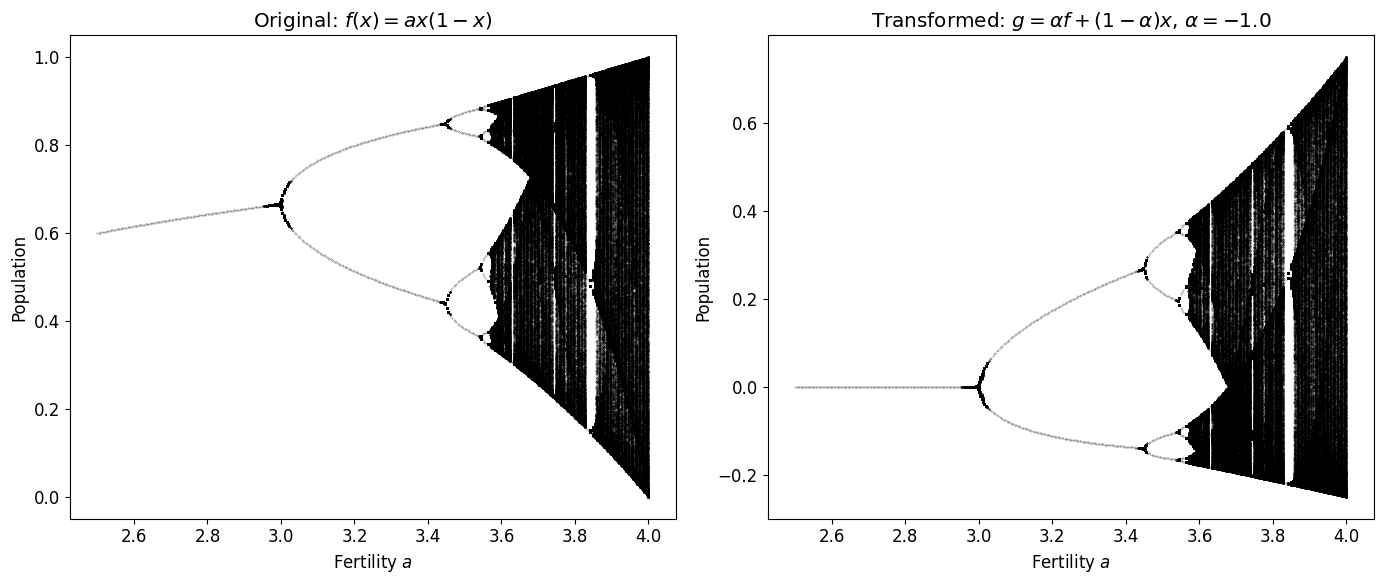

In [4]:
a_range = np.linspace(2.5, 4.0, 400)
x0_samples = np.linspace(0.1, 0.9, 30)
alpha_bif = -1.0  # Fixed alpha for comparison (as in original scripts)

# Original bifurcation
a_orig, x_orig = compute_bifurcation(logistic, a_range, x0_samples, n_iter=500, n_discard=400)
# Transformed bifurcation
a_trans, x_trans = compute_bifurcation_transformed(logistic, alpha_bif, a_range, x0_samples, n_iter=500, n_discard=400)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(a_orig, x_orig, s=0.1, c='black', alpha=0.5)
ax1.set_xlabel('Fertility $a$')
ax1.set_ylabel('Population')
ax1.set_title('Original: $f(x) = ax(1-x)$')

ax2.scatter(a_trans, x_trans, s=0.1, c='black', alpha=0.5)
ax2.set_xlabel('Fertility $a$')
ax2.set_ylabel('Population')
ax2.set_title(rf'Transformed: $g = \alpha f + (1-\alpha)x$, $\alpha = {alpha_bif}$')

plt.tight_layout()
plt.show()

## 5. Part II — Eigenstates as Fixed Points

### 5.1 The Projective Fixed-Point Argument

In **projective Hilbert space** $\mathbb{P}(\mathcal{H})$ — the space of rays $[|\psi\rangle]$ where $|\psi\rangle \sim c|\psi\rangle$ — the eigenvalue equation $\hat{A}|\psi\rangle = \lambda|\psi\rangle$ states that $[|\psi\rangle]$ is a **fixed point** of the projective action of $\hat{A}$.

Define the projective map:

$$\Pi_A : [|\psi\rangle] \mapsto \left[\frac{\hat{A}|\psi\rangle}{\|\hat{A}|\psi\rangle\|}\right]$$

Then $[|\psi_k\rangle]$ is a fixed point of $\Pi_A$ if and only if $|\psi_k\rangle$ is an eigenstate of $\hat{A}$.

The **stability** of these fixed points is determined by the eigenvalue ratios $|\lambda_k / \lambda_{\max}|$:
- The eigenstate with largest $|\lambda|$ is the **attracting** fixed point of $\Pi_A$
- All other eigenstates are **repelling** (analogous to unstable fixed points)

**This is not just an analogy — it is the mathematical content of power iteration** [Ref 6, Ch. 25].

### 5.2 Inverse Power Iteration as Fixed-Point Iteration with Shift

Inverse power iteration with shift $\sigma$ uses $(\hat{A} - \sigma I)^{-1}$ as the iterating operator. This transforms the eigenvalue landscape: the eigenstate nearest $\sigma$ becomes the **dominant** (attracting) fixed point, because its transformed eigenvalue $1/(\lambda_k - \sigma)$ is largest.

This is precisely a **spectral shift** — changing which fixed point is stable, analogous to the alpha-transform changing which fixed point of the logistic map is attracting.

In [5]:
# Harmonic oscillator eigenvalues via matrix diagonalization
N = 500
x_grid = np.linspace(-8, 8, N)

eigenvalues, eigenvectors = solve_eigenstates(harmonic, x_grid, n_states=8)
exact = np.arange(8) + 0.5

print("Harmonic oscillator eigenvalues:")
print(f"{'n':>3}  {'Computed':>12}  {'Exact':>8}  {'Error':>10}")
for i in range(8):
    print(f"{i:3d}  {eigenvalues[i]:12.6f}  {exact[i]:8.1f}  {abs(eigenvalues[i] - exact[i]):10.2e}")

Harmonic oscillator eigenvalues:
  n      Computed     Exact       Error
  0      0.499968       0.5    3.21e-05
  1      1.499839       1.5    1.61e-04
  2      2.499582       2.5    4.18e-04
  3      3.499197       3.5    8.03e-04
  4      4.498682       4.5    1.32e-03
  5      5.498039       5.5    1.96e-03
  6      6.497268       6.5    2.73e-03
  7      7.496368       7.5    3.63e-03


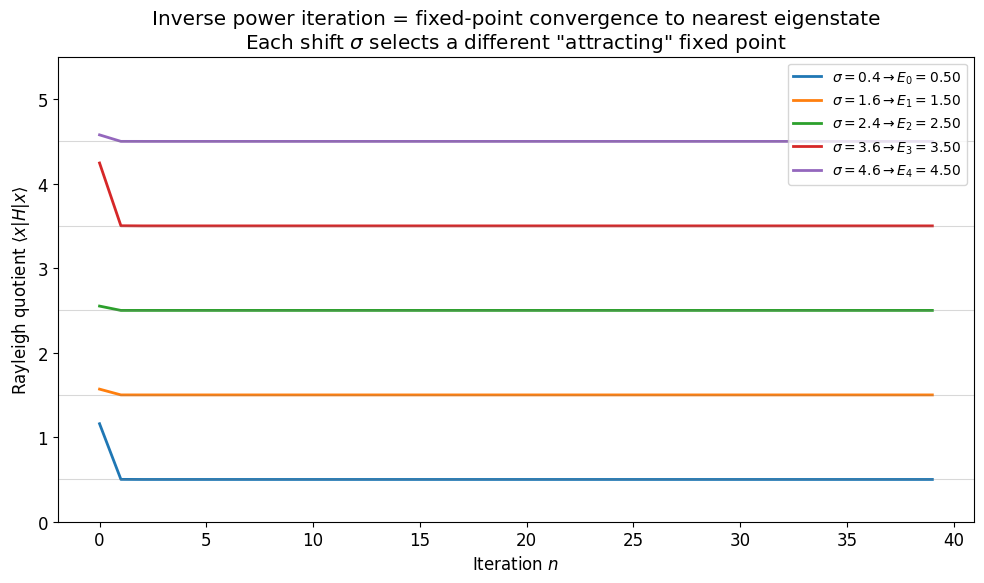

In [6]:
# Inverse power iteration: convergence to different eigenstates via shift
H = discretize_hamiltonian(harmonic, x_grid)
evals_full = eigh(H, eigvals_only=True)

fig, ax = plt.subplots(figsize=(10, 6))
shifts = [0.4, 1.6, 2.4, 3.6, 4.6]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for sigma, color in zip(shifts, colors):
    rq = inverse_power_iteration(H, sigma, n_iter=40)
    nearest_idx = np.argmin(np.abs(evals_full - sigma))
    nearest_E = evals_full[nearest_idx]
    ax.plot(rq, color=color, lw=2,
            label=rf'$\sigma={sigma:.1f} \to E_{nearest_idx}={nearest_E:.2f}$')

for i in range(5):
    ax.axhline(evals_full[i], color='gray', alpha=0.3, lw=0.8)

ax.set_xlabel('Iteration $n$')
ax.set_ylabel('Rayleigh quotient $\\langle x|H|x\\rangle$')
ax.set_title('Inverse power iteration = fixed-point convergence to nearest eigenstate\n'
             'Each shift $\\sigma$ selects a different "attracting" fixed point')
ax.legend(fontsize=10)
ax.set_ylim(0, 5.5)
plt.tight_layout()
plt.show()

### 5.3 Alpha-Transform as Eigenstate Selector

Instead of a spectral shift, we can use the alpha-transform on the normalized power iteration:

$$|x_{n+1}\rangle = \alpha \frac{\hat{A}|x_n\rangle}{\|\hat{A}|x_n\rangle\|} + (1-\alpha)|x_n\rangle$$

Different values of $\alpha$ change the fixed-point stability landscape in projective space, potentially allowing access to eigenstates that power iteration alone cannot reach.

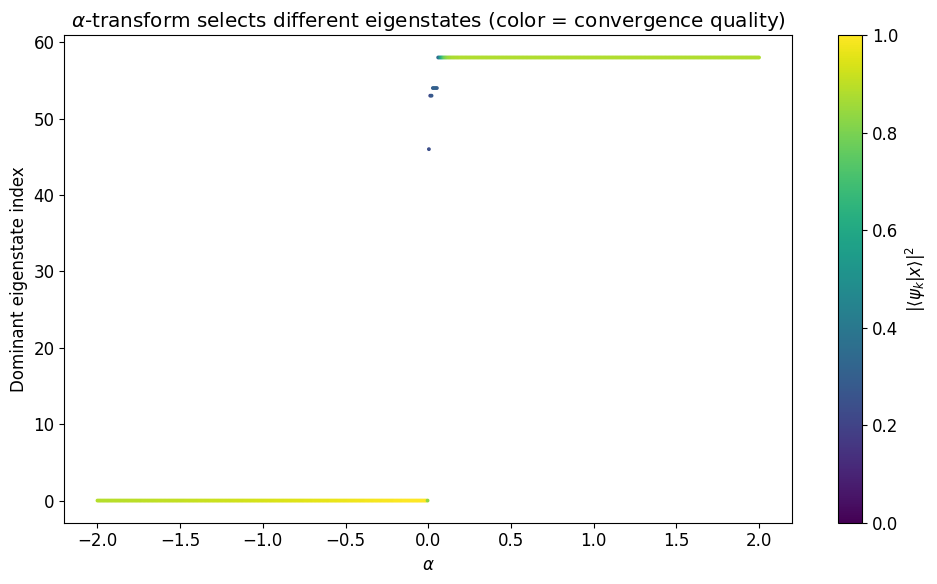

In [7]:
# Alpha-scan: which eigenstate does the iteration converge to for each alpha?
N_small = 60
x_small = np.linspace(-5, 5, N_small)
H_small = discretize_hamiltonian(harmonic, x_small)

alphas = np.linspace(-2.0, 2.0, 500)
rng = np.random.default_rng(7)
x0 = rng.standard_normal(N_small)

dom, quality, ev_small = alpha_eigenstate_scan(H_small, x0, alphas, n_iter=500)

fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(alphas, dom, c=quality, cmap='viridis', s=3, vmin=0, vmax=1)
ax.set_xlabel(r'$\alpha$')
ax.set_ylabel('Dominant eigenstate index')
ax.set_title(r'$\alpha$-transform selects different eigenstates (color = convergence quality)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$|\langle\psi_k|x\rangle|^2$')
plt.tight_layout()
plt.show()

## 6. Part III — Turbiner's Riccati-Bloch Method as Dynamical System

### 6.1 The Riccati-Bloch Equation

Using Turbiner's substitution $\psi(x) = \exp\!\left(-\int^x y(t)\,dt\right)$, the Schrödinger equation becomes [Ref 1]:

$$y'(x) = y(x)^2 - 2V(x) + 2E$$

This is a **Riccati equation** — a first-order nonlinear ODE. The critical observation:

- At an eigenvalue $E = E_n$: the trajectory $y(x)$ remains **bounded** for all $x$
- Away from an eigenvalue: $y(x)$ develops a **Riccati singularity** (diverges at finite $x$)

This means **eigenvalues are the parameter values for which a nonlinear dynamical system has bounded (non-divergent) trajectories**. This is a direct analog of how, in bifurcation theory, certain parameter values separate qualitatively different dynamical behaviors.

### 6.2 Spectral Scanning via the Shooting Method

We sweep $E$ and for each trial energy integrate the Schrödinger equation forward from $x = 0$ with appropriate boundary conditions. At eigenvalues, $\psi(x_{\max}) \to 0$; elsewhere it diverges.

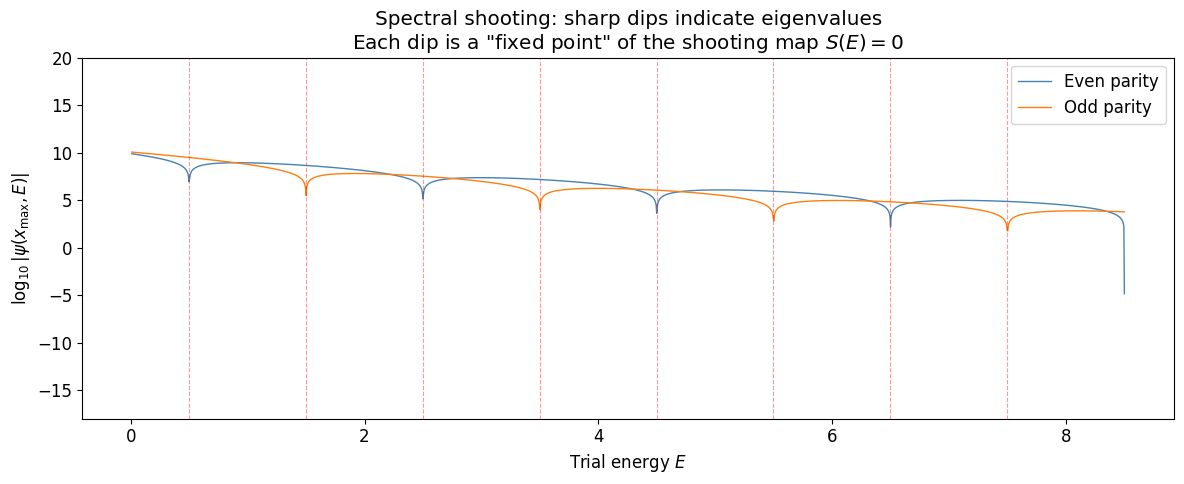

In [8]:
# Spectral scan: find eigenvalues as zeros of the shooting function
E_range = np.linspace(0.01, 8.5, 2000)
x_span = (0.0, 7.0)

psi_even = spectral_scan(harmonic, E_range, x_span, parity='even')
psi_odd = spectral_scan(harmonic, E_range, x_span, parity='odd')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(E_range, np.log10(np.abs(psi_even) + 1e-20), 'steelblue', lw=1.0, label='Even parity')
ax.plot(E_range, np.log10(np.abs(psi_odd) + 1e-20), '#ff7f0e', lw=1.0, label='Odd parity')

for i in range(8):
    ev = evals_full[i]
    if ev <= 8.5:
        ax.axvline(ev, color='red', alpha=0.4, lw=0.8, ls='--')

ax.set_xlabel('Trial energy $E$')
ax.set_ylabel(r'$\log_{10}|\psi(x_{\max}, E)|$')
ax.set_title('Spectral shooting: sharp dips indicate eigenvalues\n'
             r'Each dip is a "fixed point" of the shooting map $S(E) = 0$')
ax.legend()
ax.set_ylim(-18, 20)
plt.tight_layout()
plt.show()

### 6.3 Riccati Trajectories: Bounded if and only if $E = E_n$

The Riccati-Bloch equation $y' = y^2 - 2V + 2E$ gives bounded $y(x)$ only at eigenvalues. This is the dynamical-systems perspective on quantization: **eigenvalues are selected by a global regularity condition on a nonlinear flow.**

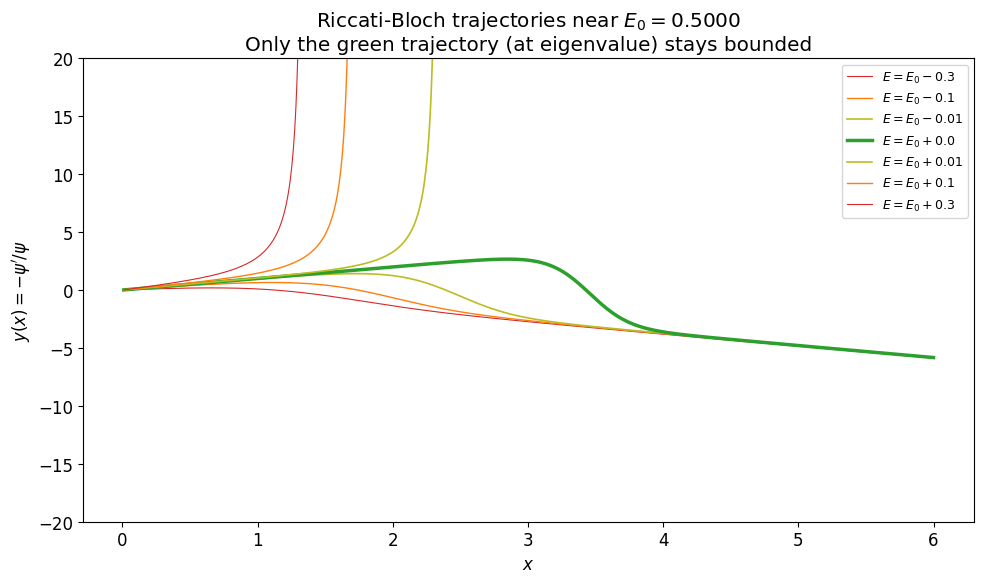

In [9]:
# Riccati trajectories near the ground state energy
E_exact = evals_full[0]

offsets = [-0.3, -0.1, -0.01, 0.0, 0.01, 0.1, 0.3]
colors_r = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#bcbd22', '#ff7f0e', '#d62728']
widths = [0.8, 1.0, 1.2, 2.5, 1.2, 1.0, 0.8]

fig, ax = plt.subplots(figsize=(10, 6))
for offset, color, w in zip(offsets, colors_r, widths):
    E_trial = E_exact + offset
    sol = riccati_solve(harmonic, E_trial, (0.01, 6.0), y0=0.01)
    label = rf'$E = E_0 {"+" if offset >= 0 else ""}{offset}$'
    ax.plot(sol.t, sol.y[0], color=color, lw=w, label=label)

ax.set_xlabel('$x$')
ax.set_ylabel(r"$y(x) = -\psi'/\psi$")
ax.set_title(f'Riccati-Bloch trajectories near $E_0 = {E_exact:.4f}$\n'
             'Only the green trajectory (at eigenvalue) stays bounded')
ax.set_ylim(-20, 20)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 6.4 Alpha-Relaxed Riccati: Stabilizing Excited States

The alpha-transform can be applied to the discretized Riccati equation:

$$y_{n+1} = \alpha\left[y_n + h\left(y_n^2 - 2V(x_n) + 2E\right)\right] + (1-\alpha)y_n$$

This is a direct bridge from the 2017 alpha-transform work to Turbiner's framework. The hypothesis: **different $\alpha$ values can stabilize Riccati trajectories for excited states that are normally repulsive** — just as the alpha-transform stabilizes unstable fixed points of the logistic map.

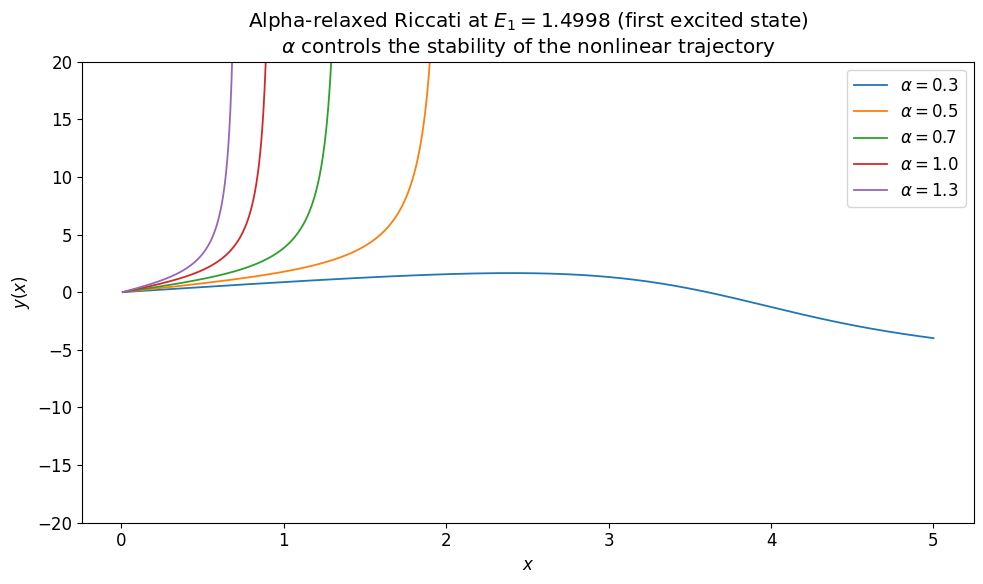

In [10]:
# Alpha-relaxed Riccati for the first excited state
E1 = evals_full[1]
x_alpha_grid = np.linspace(0.01, 5.0, 1500)

alphas_demo = [0.3, 0.5, 0.7, 1.0, 1.3]
colors_a = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(10, 6))
for alpha_val, color in zip(alphas_demo, colors_a):
    y_traj = riccati_alpha(harmonic, E1, x_alpha_grid, y0=0.01, alpha=alpha_val)
    ax.plot(x_alpha_grid, y_traj, color=color, lw=1.3, label=rf'$\alpha = {alpha_val}$')

ax.set_xlabel('$x$')
ax.set_ylabel('$y(x)$')
ax.set_title(rf'Alpha-relaxed Riccati at $E_1 = {E1:.4f}$ (first excited state)' + '\n'
             r'$\alpha$ controls the stability of the nonlinear trajectory')
ax.set_ylim(-20, 20)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Part IV — Eigenvalue Detection via Fixed-Point Methods

### 7.1 Automated Eigenvalue Detection

We can detect eigenvalues by finding the minima of $|\psi(x_{\max}, E)|$ — these are the values of $E$ where the shooting map $S(E) = \psi(x_{\max})$ has a zero (fixed point). This works for arbitrary potentials, including those without known analytic solutions.

In [11]:
# Eigenvalue detection for the harmonic oscillator
E_fine = np.linspace(0.01, 8.0, 5000)
E_detected = detect_eigenvalues(harmonic, E_fine, x_span=(0.0, 7.0), order=20)

print("Eigenvalue detection via Riccati/shooting fixed-point method:")
print(f"{'Detected':>12}  {'Exact (matrix)':>14}  {'Exact (analytic)':>16}  {'Error':>10}")
for E_det in E_detected:
    near_idx = np.argmin(np.abs(evals_full - E_det))
    E_mat = evals_full[near_idx]
    E_ana = near_idx + 0.5
    print(f"{E_det:12.5f}  {E_mat:14.5f}  {E_ana:16.1f}  {abs(E_det - E_ana):10.2e}")

Eigenvalue detection via Riccati/shooting fixed-point method:
    Detected  Exact (matrix)  Exact (analytic)       Error
     0.50068         0.49997               0.5    6.84e-04
     1.49963         1.49984               1.5    3.66e-04
     2.50018         2.49958               2.5    1.82e-04
     3.50073         3.49920               3.5    7.30e-04
     4.49968         4.49868               4.5    3.20e-04
     5.50023         5.49804               5.5    2.28e-04
     6.50078         6.49727               6.5    7.76e-04
     7.49973         7.49637               7.5    2.74e-04


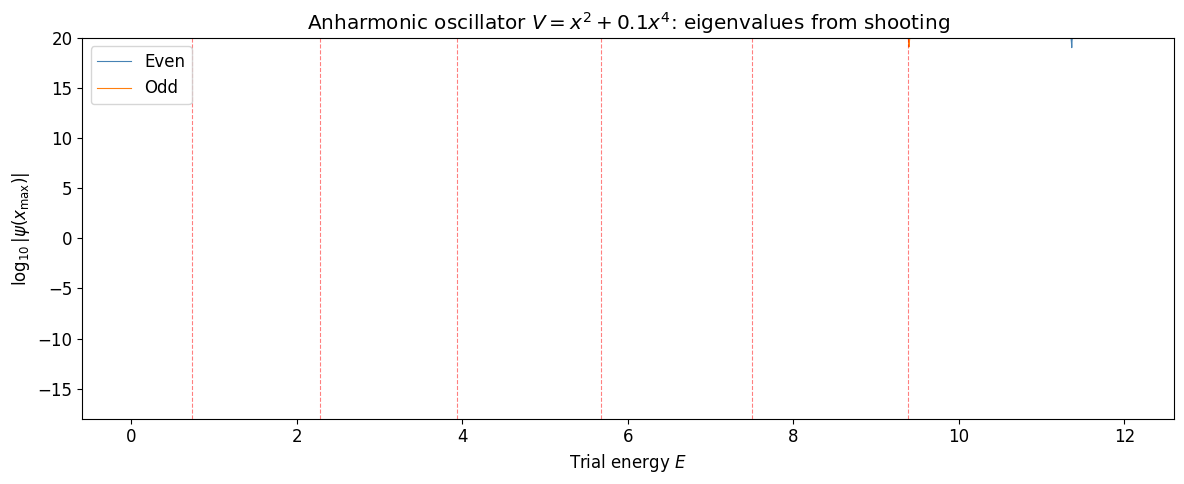


Anharmonic oscillator eigenvalue detection:
    Detected   Matrix diag       Error
      0.7416        0.7408    7.99e-04
      2.2809        2.2819    1.02e-03
      3.9320        3.9316    4.01e-04
      5.6752        5.6735    1.65e-03
      7.5023        7.4963    5.96e-03
      9.3973        9.3917    5.61e-03
     11.3643       11.3533    1.10e-02


In [12]:
# Now for the anharmonic oscillator — no analytic solution exists
V_anh = lambda x: anharmonic(x, g=0.1)
evals_anh = eigh(discretize_hamiltonian(V_anh, x_grid), eigvals_only=True)

E_anh_range = np.linspace(0.01, 12.0, 3000)
E_anh_detected = detect_eigenvalues(V_anh, E_anh_range, x_span=(0.0, 7.0), order=10)

psi_anh_even = spectral_scan(V_anh, E_anh_range, (0.0, 7.0), parity='even')
psi_anh_odd = spectral_scan(V_anh, E_anh_range, (0.0, 7.0), parity='odd')

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(E_anh_range, np.log10(np.abs(psi_anh_even) + 1e-20), 'steelblue', lw=0.8, label='Even')
ax.plot(E_anh_range, np.log10(np.abs(psi_anh_odd) + 1e-20), '#ff7f0e', lw=0.8, label='Odd')
for i in range(6):
    ev = evals_anh[i]
    if ev <= 12.0:
        ax.axvline(ev, color='red', alpha=0.5, lw=0.8, ls='--')
ax.set_xlabel('Trial energy $E$')
ax.set_ylabel(r'$\log_{10}|\psi(x_{\max})|$')
ax.set_title('Anharmonic oscillator $V = x^2 + 0.1x^4$: eigenvalues from shooting')
ax.legend()
ax.set_ylim(-18, 20)
plt.tight_layout()
plt.show()

print("\nAnharmonic oscillator eigenvalue detection:")
print(f"{'Detected':>12}  {'Matrix diag':>12}  {'Error':>10}")
for E_det in E_anh_detected:
    near_idx = np.argmin(np.abs(evals_anh - E_det))
    print(f"{E_det:12.4f}  {evals_anh[near_idx]:12.4f}  {abs(E_det - evals_anh[near_idx]):10.2e}")

## 8. Prediction-First Experiments

Rather than a literature review, we go straight to testable claims. If any of these show a genuine advantage or surprising result, *then* we check the literature for prior art.

### Experiment 1: Speed — Riccati-Shooting vs. Numerov vs. Matrix Diagonalization

**Claim to test:** The Riccati-Bloch shooting method might have different speed/accuracy tradeoffs than the standard Numerov method, especially for potentials where eigenvalues are sparse or high-lying.

**Method:** For each potential (harmonic, anharmonic, double well, Morse), measure wall-clock time and eigenvalue accuracy across all three methods at comparable grid sizes.

In [2]:
import time
from petrification.quantum import numerov_detect, numerov_shoot, numerov_scan

# --- Benchmark setup ---
potentials = {
    'Harmonic': (harmonic, (-8, 8), (0, 7), 8),
    'Anharmonic': (lambda x: anharmonic(x, g=0.1), (-8, 8), (0, 7), 7),
    'Double well': (double_well, (-4, 4), (0, 4), 4),
    'Morse': (lambda x: morse(x, D=10, alpha=1.0, x0=0.0), (-2, 8), (0, 6), 5),
}

grid_sizes = [200, 500, 1000]
E_scan = np.linspace(0.01, 12.0, 2000)

print("=" * 80)
print("EXPERIMENT 1: Speed & Accuracy Benchmark")
print("=" * 80)

results_table = []

for pot_name, (V, x_lim, x_span, n_expect) in potentials.items():
    print(f"\n{'─' * 60}")
    print(f"  {pot_name} potential")
    print(f"{'─' * 60}")
    
    for N in grid_sizes:
        x_g = np.linspace(x_lim[0], x_lim[1], N)
        x_shoot = np.linspace(x_span[0], x_span[1], N)
        
        # Method 1: Matrix diagonalization
        t0 = time.perf_counter()
        E_mat = eigh(discretize_hamiltonian(V, x_g), eigvals_only=True)[:n_expect]
        t_mat = time.perf_counter() - t0
        
        # Method 2: Numerov + bisection
        t0 = time.perf_counter()
        E_num = numerov_detect(V, E_scan, x_shoot, order=15)[:n_expect]
        t_num = time.perf_counter() - t0
        
        # Method 3: Riccati-Bloch shooting (our existing detect_eigenvalues)
        t0 = time.perf_counter()
        E_ric = detect_eigenvalues(V, E_scan, x_span=x_span, order=15)[:n_expect]
        t_ric = time.perf_counter() - t0
        
        # Compute errors (use matrix diag at N=1000 as ground truth for comparison)
        x_ref = np.linspace(x_lim[0], x_lim[1], 2000)
        E_ref = eigh(discretize_hamiltonian(V, x_ref), eigvals_only=True)[:n_expect]
        
        def max_err(E_found, E_true):
            if len(E_found) == 0:
                return float('inf')
            errors = []
            for e in E_found:
                idx = np.argmin(np.abs(E_true - e))
                errors.append(abs(e - E_true[idx]))
            return np.max(errors)
        
        err_mat = max_err(E_mat, E_ref)
        err_num = max_err(E_num, E_ref)
        err_ric = max_err(E_ric, E_ref)
        
        n_found_num = len(E_num)
        n_found_ric = len(E_ric)
        
        print(f"\n  N = {N}:")
        print(f"    {'Method':<22} {'Time (s)':>10} {'Max Error':>12} {'Found':>6}")
        print(f"    {'Matrix diag':<22} {t_mat:10.4f} {err_mat:12.2e} {n_expect:6d}")
        print(f"    {'Numerov+bisect':<22} {t_num:10.4f} {err_num:12.2e} {n_found_num:6d}")
        print(f"    {'Riccati-Bloch shoot':<22} {t_ric:10.4f} {err_ric:12.2e} {n_found_ric:6d}")
        
        results_table.append({
            'potential': pot_name, 'N': N,
            't_mat': t_mat, 't_num': t_num, 't_ric': t_ric,
            'err_mat': err_mat, 'err_num': err_num, 'err_ric': err_ric,
            'n_num': n_found_num, 'n_ric': n_found_ric,
        })

print("\n" + "=" * 80)
print("Key question: Does ANY method show a clear advantage in a specific regime?")
print("=" * 80)

EXPERIMENT 1: Speed & Accuracy Benchmark

────────────────────────────────────────────────────────────
  Harmonic potential
────────────────────────────────────────────────────────────

  N = 200:
    Method                   Time (s)    Max Error  Found
    Matrix diag                0.0031     2.27e-02      8
    Numerov+bisect             1.1451     2.23e-04      8
    Riccati-Bloch shoot      102.8574     2.58e-03      8

  N = 500:
    Method                   Time (s)    Max Error  Found
    Matrix diag                0.0078     3.41e-03      8
    Numerov+bisect             2.6697     2.26e-04      8
    Riccati-Bloch shoot      102.2411     2.58e-03      8

  N = 1000:
    Method                   Time (s)    Max Error  Found
    Matrix diag                0.0509     6.80e-04      8
    Numerov+bisect             5.3954     2.26e-04      8
    Riccati-Bloch shoot      101.8557     2.58e-03      8

────────────────────────────────────────────────────────────
  Anharmonic potenti

### Experiment 2: Alpha-Relaxed Riccati — Can It Find What Others Miss?

**Claim to test:** Standard shooting methods (Numerov, RK45) integrate *forward* from a boundary condition and check the other boundary. They work well for low-lying states but can struggle for:
- **High-lying states** (many oscillations → accumulated error)
- **Double wells** (exponentially small splittings are hard to resolve)
- **Near-degenerate states** (close eigenvalues get confused)

The alpha-relaxed Riccati adds a damping parameter. If it's doing something non-trivial, it might stabilize trajectories for states where standard shooting diverges.

**Specific prediction:** For the double-well potential, the tunnel-splitting between quasi-degenerate pairs should be detectable via Riccati with properly tuned alpha, even when standard shooting with the same grid spacing fails to resolve them.

Double-well eigenvalues (ground truth, N=3000):
  E_0 = 0.86957967  pair 0
  E_1 = 1.66142300  pair 0  Δ=7.918433e-01
  E_2 = 3.54377312  pair 1
  E_3 = 5.66533491  pair 1  Δ=2.121562e+00
  E_4 = 8.12611766  pair 2
  E_5 = 10.84346674  pair 2  Δ=2.717349e+00
  E_6 = 13.78307023  pair 3
  E_7 = 16.91864981  pair 3  Δ=3.135580e+00

────────────────────────────────────────────────────────────
Standard Riccati shooting: can it resolve the splittings?
────────────────────────────────────────────────────────────

  n_E = 500: found 4 eigenvalues, matched 4/6
    Pair 0: split=7.953908e-01 (true=7.918433e-01, rel_err=4.48e-03)
    Pair 1: split=2.126453e+00 (true=2.121562e+00, rel_err=2.31e-03)

  n_E = 2000: found 4 eigenvalues, matched 4/6
    Pair 0: split=7.941971e-01 (true=7.918433e-01, rel_err=2.97e-03)
    Pair 1: split=2.123262e+00 (true=2.121562e+00, rel_err=8.01e-04)

  n_E = 8000: found 4 eigenvalues, matched 4/6
    Pair 0: split=7.918740e-01 (true=7.918433e-01, rel_err=3.87e-05)


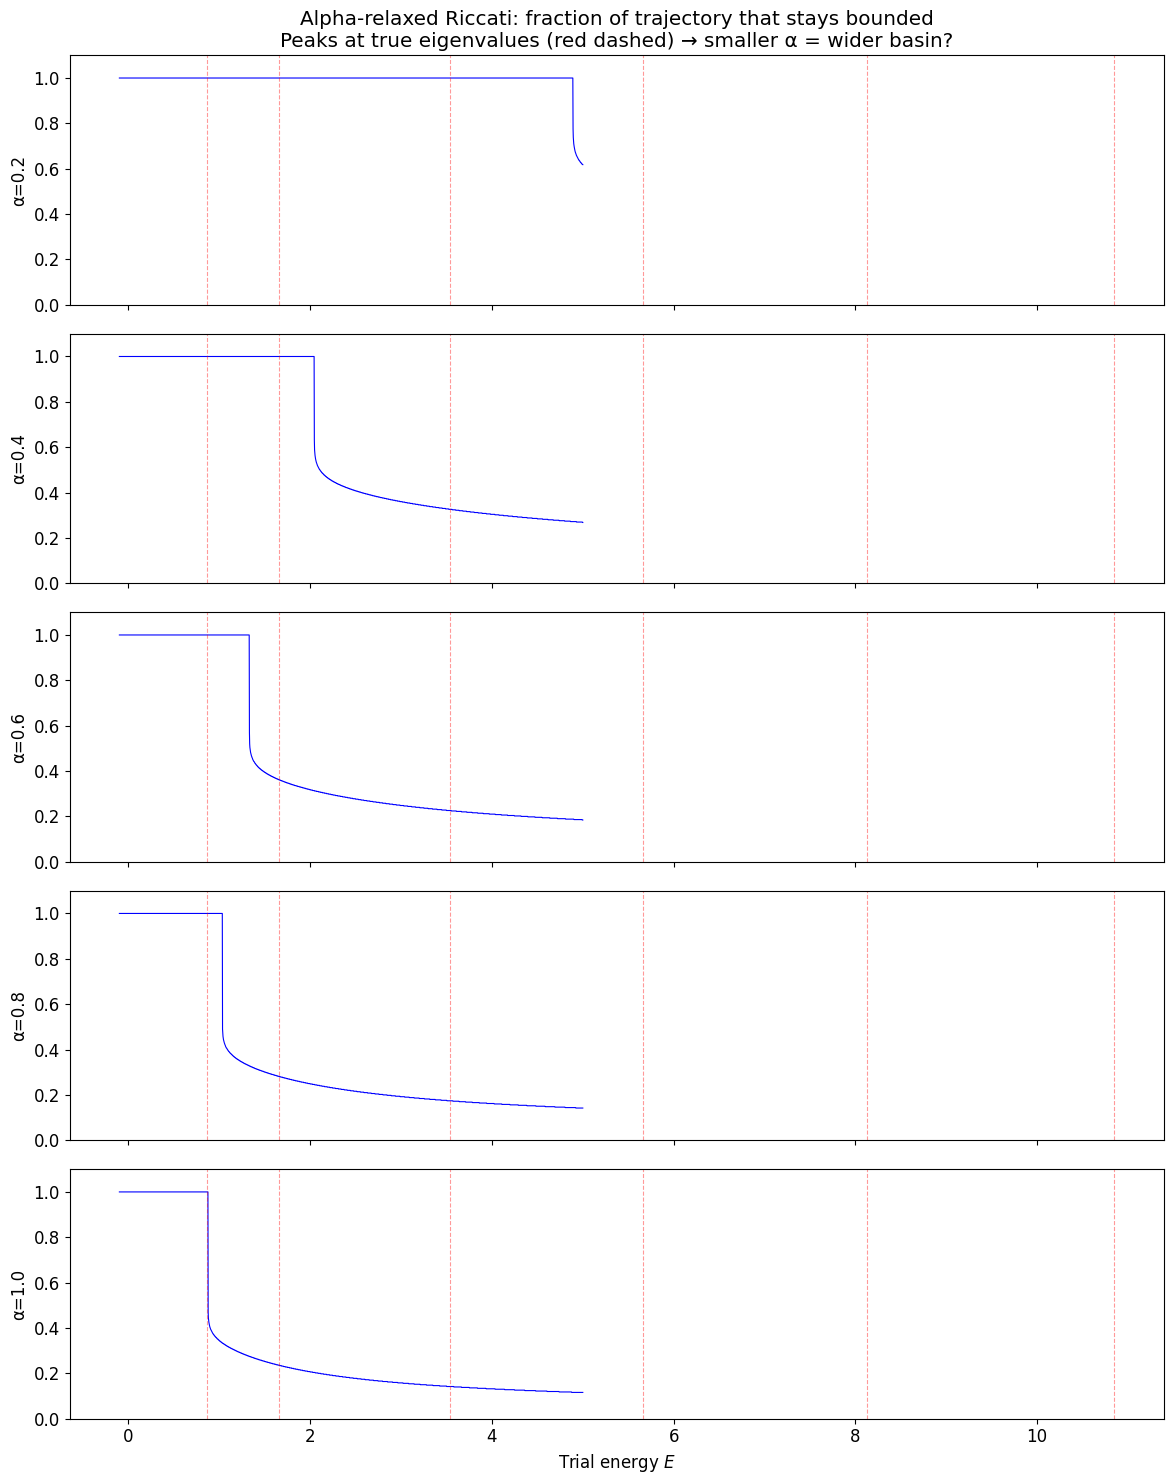


Basin width around E_0 (ground state) for each alpha:
  α = 0.2: 1000/1000 bounded → basin width ≈ 1.0000
  α = 0.4: 1000/1000 bounded → basin width ≈ 1.0000
  α = 0.6: 961/1000 bounded → basin width ≈ 0.9610
  α = 0.8: 664/1000 bounded → basin width ≈ 0.6640
  α = 1.0: 507/1000 bounded → basin width ≈ 0.5070


In [3]:
# Experiment 2: Double-well tunnel splitting test
# The double_well V(x) = (x^2 - 1)^2 has quasi-degenerate pairs.
# Can alpha-relaxed Riccati resolve the splitting better than standard shooting?

V_dw = lambda x: double_well(x, a=1.0)

# Ground truth: high-resolution matrix diag
x_truth = np.linspace(-6, 6, 3000)
E_truth = eigh(discretize_hamiltonian(V_dw, x_truth), eigvals_only=True)[:8]
splittings_truth = [E_truth[i+1] - E_truth[i] for i in range(0, 8, 2)]

print("Double-well eigenvalues (ground truth, N=3000):")
for i, e in enumerate(E_truth):
    pair_label = f"  pair {i//2}" if i % 2 == 0 else f"  pair {i//2}  Δ={e - E_truth[i-1]:.6e}"
    print(f"  E_{i} = {e:.8f}{pair_label}")

# Standard shooting at various grid resolutions
print(f"\n{'─' * 60}")
print("Standard Riccati shooting: can it resolve the splittings?")
print(f"{'─' * 60}")

for n_E in [500, 2000, 8000]:
    E_scan_dw = np.linspace(-0.1, 8.0, n_E)
    E_det = detect_eigenvalues(V_dw, E_scan_dw, x_span=(0.0, 4.5), order=5)
    
    # Try to match pairs
    found_pairs = []
    used = set()
    for e_true in E_truth[:6]:
        closest = np.argmin(np.abs(E_det - e_true))
        if closest not in used and abs(E_det[closest] - e_true) < 0.5:
            found_pairs.append(E_det[closest])
            used.add(closest)
    
    print(f"\n  n_E = {n_E}: found {len(E_det)} eigenvalues, matched {len(found_pairs)}/6")
    if len(found_pairs) >= 2:
        for i in range(0, min(len(found_pairs), 6), 2):
            if i + 1 < len(found_pairs):
                split = found_pairs[i+1] - found_pairs[i]
                true_split = E_truth[i+1] - E_truth[i]
                print(f"    Pair {i//2}: split={split:.6e} (true={true_split:.6e}, "
                      f"rel_err={abs(split-true_split)/true_split:.2e})")

# Alpha-relaxed Riccati: scan alpha values to see if any improve detection
print(f"\n{'─' * 60}")
print("Alpha-relaxed Riccati: does damping help?")
print(f"{'─' * 60}")

x_ric_grid = np.linspace(0, 5, 500)
E_fine_dw = np.linspace(-0.1, 5.0, 2000)

# For each trial eigenvalue, check if the Riccati trajectory stays bounded
# with different alpha values
alpha_test = [0.2, 0.4, 0.6, 0.8, 1.0]
fig, axes = plt.subplots(len(alpha_test), 1, figsize=(12, 3*len(alpha_test)), sharex=True)

for idx, alpha_r in enumerate(alpha_test):
    divergence_measure = np.zeros(len(E_fine_dw))
    
    for j, E_trial in enumerate(E_fine_dw):
        traj = riccati_alpha(V_dw, E_trial, x_ric_grid, y0=0.0, alpha=alpha_r, max_y=1e6)
        # Measure: how long does the trajectory stay bounded?
        bounded = np.sum(np.abs(traj) < 100)
        divergence_measure[j] = bounded / len(x_ric_grid)
    
    axes[idx].plot(E_fine_dw, divergence_measure, 'b-', lw=0.8)
    for e in E_truth[:6]:
        axes[idx].axvline(e, color='red', alpha=0.4, lw=0.8, ls='--')
    axes[idx].set_ylabel(f'α={alpha_r}')
    axes[idx].set_ylim(0, 1.1)

axes[-1].set_xlabel('Trial energy $E$')
axes[0].set_title('Alpha-relaxed Riccati: fraction of trajectory that stays bounded\n'
                   'Peaks at true eigenvalues (red dashed) → smaller α = wider basin?')
plt.tight_layout()
plt.show()

# Check: does lower alpha widen the convergence basin around eigenvalues?
print("\nBasin width around E_0 (ground state) for each alpha:")
E_gs = E_truth[0]
E_fine_zoom = np.linspace(E_gs - 0.5, E_gs + 0.5, 1000)

for alpha_r in alpha_test:
    bounded_count = 0
    for E_trial in E_fine_zoom:
        traj = riccati_alpha(V_dw, E_trial, x_ric_grid, y0=0.0, alpha=alpha_r, max_y=1e6)
        if np.all(np.abs(traj) < 100):
            bounded_count += 1
    basin_fraction = bounded_count / len(E_fine_zoom)
    basin_width = basin_fraction * (E_fine_zoom[-1] - E_fine_zoom[0])
    print(f"  α = {alpha_r}: {bounded_count}/{len(E_fine_zoom)} bounded "
          f"→ basin width ≈ {basin_width:.4f}")

### Experiment 3: Reverse Direction — Spectral Properties of Chaotic Maps

**The big question:** Can we run the eigenstate-fixed-point connection *backwards*? If quantum eigenstates are fixed points of projective operators, and if Turbiner's method converts between the two pictures, then maybe we can construct a "Hamiltonian-like" operator for a chaotic map and extract useful dynamical information from its spectrum.

The natural operator for this is the **Frobenius-Perron (transfer) operator** $\mathcal{L}$, which propagates probability densities under the map: $(\mathcal{L}\rho)(x) = \sum_{y: f(y)=x} \rho(y)/|f'(y)|$.

**Predictions to test:**
1. The leading eigenvalue of $\mathcal{L}$ should be 1 (conservation of probability), with the corresponding eigenvector being the invariant measure.
2. The gap between eigenvalue 1 and the second-largest eigenvalue should relate to the **decay rate of correlations** (mixing rate).
3. As we vary the logistic parameter $a$ through the Feigenbaum cascade, the spectrum of $\mathcal{L}$ should show structure: at period-doubling points, new eigenvalues should appear at specific values related to the period.
4. At $a = 4$ (fully chaotic), the known invariant measure is $\rho(x) = \frac{1}{\pi\sqrt{x(1-x)}}$ — the Frobenius-Perron eigenvector should match this.

EXPERIMENT 3: Spectral Properties of Chaotic Maps

Logistic map a=4, N=300 bins
Top 10 eigenvalues of Frobenius-Perron operator:
  λ_0 = +1.000000 +0.000000j  |λ| = 1.000000
  λ_1 = +0.141336 +0.577537j  |λ| = 0.594579
  λ_2 = +0.141336 -0.577537j  |λ| = 0.594579
  λ_3 = -0.421086 +0.381001j  |λ| = 0.567868
  λ_4 = -0.421086 -0.381001j  |λ| = 0.567868
  λ_5 = -0.535177 +0.000000j  |λ| = 0.535177
  λ_6 = +0.214477 -0.390141j  |λ| = 0.445208
  λ_7 = +0.214477 +0.390141j  |λ| = 0.445208
  λ_8 = -0.367254 -0.247786j  |λ| = 0.443027
  λ_9 = -0.367254 +0.247786j  |λ| = 0.443027

Prediction 1: λ_0 = 1? → λ_0 = 1.000000


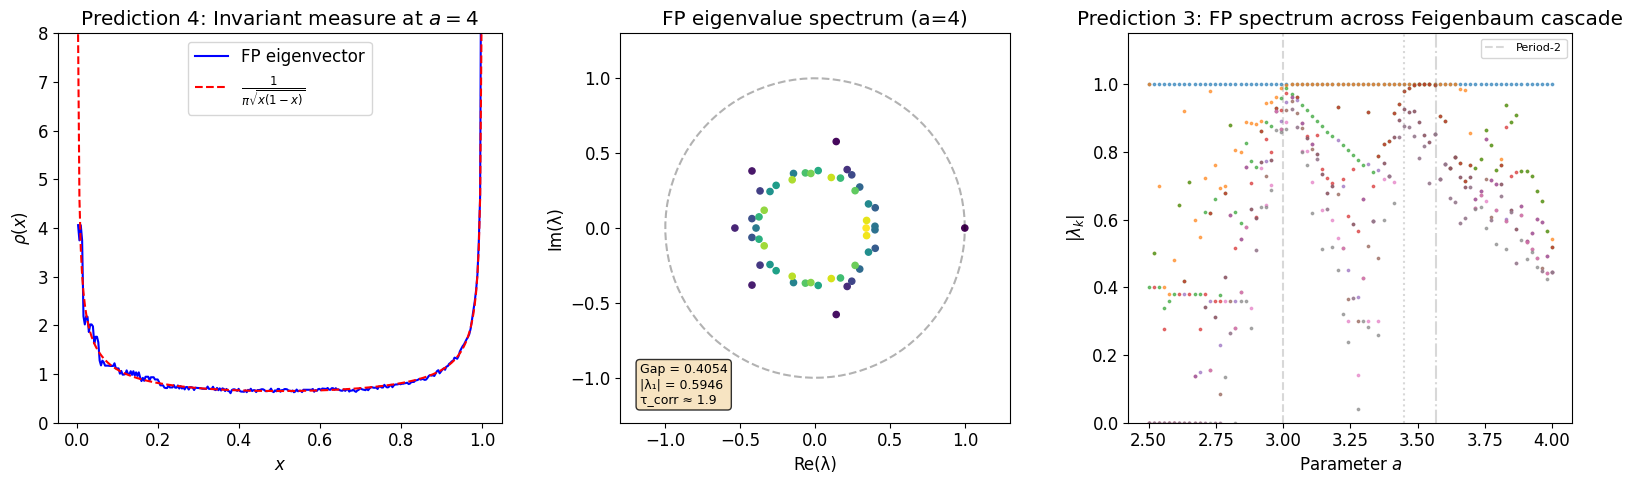


Prediction 2: Spectral gap and decay of correlations
  |λ_0| = 1.000000 (should be 1)
  |λ_1| = 0.594579
  Spectral gap = 0.405421
  Implied correlation decay time τ ≈ 1.92

  Known Lyapunov exponent at a=4: λ_Lyap = ln(2) = 0.693147
  Can we extract it from the FP spectrum?


In [4]:
# Experiment 3a: Frobenius-Perron operator for the logistic map
from petrification.quantum import frobenius_perron_matrix

print("=" * 80)
print("EXPERIMENT 3: Spectral Properties of Chaotic Maps")
print("=" * 80)

# --- Test at a = 4 (fully chaotic, known invariant measure) ---
N_fp = 300
L_4, bins_4 = frobenius_perron_matrix(logistic, 4.0, N=N_fp)

# Eigendecomposition
evals_L, evecs_L = np.linalg.eig(L_4)

# Sort by magnitude
order = np.argsort(np.abs(evals_L))[::-1]
evals_L = evals_L[order]
evecs_L = evecs_L[:, order]

print(f"\nLogistic map a=4, N={N_fp} bins")
print(f"Top 10 eigenvalues of Frobenius-Perron operator:")
for i in range(10):
    ev = evals_L[i]
    print(f"  λ_{i} = {ev.real:+.6f} {ev.imag:+.6f}j  |λ| = {abs(ev):.6f}")

# Prediction 1: Leading eigenvalue should be 1
print(f"\nPrediction 1: λ_0 = 1? → λ_0 = {evals_L[0].real:.6f}")

# Prediction 4: Eigenvector for λ=1 should be the arcsine distribution
rho_computed = np.real(evecs_L[:, 0])
rho_computed = np.abs(rho_computed)  # density is positive
rho_computed /= np.sum(rho_computed) * (bins_4[1] - bins_4[0])  # normalize

# Known invariant measure for logistic at a=4
rho_exact = 1.0 / (np.pi * np.sqrt(bins_4 * (1 - bins_4) + 1e-30))
rho_exact /= np.sum(rho_exact) * (bins_4[1] - bins_4[0])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Invariant measure comparison
axes[0].plot(bins_4, rho_computed, 'b-', lw=1.5, label='FP eigenvector')
axes[0].plot(bins_4, rho_exact, 'r--', lw=1.5, label=r'$\frac{1}{\pi\sqrt{x(1-x)}}$')
axes[0].set_xlabel('$x$')
axes[0].set_ylabel(r'$\rho(x)$')
axes[0].set_title('Prediction 4: Invariant measure at $a=4$')
axes[0].legend()
axes[0].set_ylim(0, 8)

# Plot 2: Eigenvalue spectrum in complex plane
axes[1].scatter(np.real(evals_L[:50]), np.imag(evals_L[:50]),
                s=20, c=np.arange(50), cmap='viridis')
theta = np.linspace(0, 2*np.pi, 100)
axes[1].plot(np.cos(theta), np.sin(theta), 'k--', alpha=0.3)
axes[1].set_xlabel('Re(λ)')
axes[1].set_ylabel('Im(λ)')
axes[1].set_title('FP eigenvalue spectrum (a=4)')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.3, 1.3)
axes[1].set_ylim(-1.3, 1.3)

# Prediction 2: Spectral gap = decay of correlations
spectral_gap = abs(evals_L[0]) - abs(evals_L[1])
correlation_decay = -1.0 / np.log(abs(evals_L[1])) if abs(evals_L[1]) > 0 else float('inf')
axes[1].annotate(f'Gap = {spectral_gap:.4f}\n'
                 f'|λ₁| = {abs(evals_L[1]):.4f}\n'
                 f'τ_corr ≈ {correlation_decay:.1f}',
                 xy=(0.05, 0.05), xycoords='axes fraction', fontsize=9,
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# Plot 3: Spectrum vs. parameter a (Feigenbaum cascade)
a_values = np.linspace(2.5, 4.0, 80)
top_evals = np.zeros((len(a_values), 8), dtype=complex)

for i, a_val in enumerate(a_values):
    L_a, _ = frobenius_perron_matrix(logistic, a_val, N=150)
    ev_a = np.linalg.eigvals(L_a)
    ev_sorted = ev_a[np.argsort(np.abs(ev_a))[::-1]]
    top_evals[i, :] = ev_sorted[:8]

axes[2].set_title('Prediction 3: FP spectrum across Feigenbaum cascade')
for k in range(8):
    axes[2].scatter(a_values, np.abs(top_evals[:, k]), s=3, alpha=0.6)
axes[2].axvline(3.0, color='gray', alpha=0.3, ls='--', label='Period-2')
axes[2].axvline(3.449, color='gray', alpha=0.3, ls=':')  # Period-4
axes[2].axvline(3.5699, color='gray', alpha=0.3, ls='-.')  # Feigenbaum point
axes[2].set_xlabel('Parameter $a$')
axes[2].set_ylabel('$|\\lambda_k|$')
axes[2].set_ylim(0, 1.15)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Lyapunov exponent comparison
print(f"\nPrediction 2: Spectral gap and decay of correlations")
print(f"  |λ_0| = {abs(evals_L[0]):.6f} (should be 1)")
print(f"  |λ_1| = {abs(evals_L[1]):.6f}")
print(f"  Spectral gap = {spectral_gap:.6f}")
print(f"  Implied correlation decay time τ ≈ {correlation_decay:.2f}")

# Known Lyapunov exponent for logistic at a=4 is ln(2) ≈ 0.693
lyap_exact = np.log(2)
print(f"\n  Known Lyapunov exponent at a=4: λ_Lyap = ln(2) = {lyap_exact:.6f}")
print(f"  Can we extract it from the FP spectrum?")

EXPERIMENT 3b: Constructing an effective potential from the invariant measure


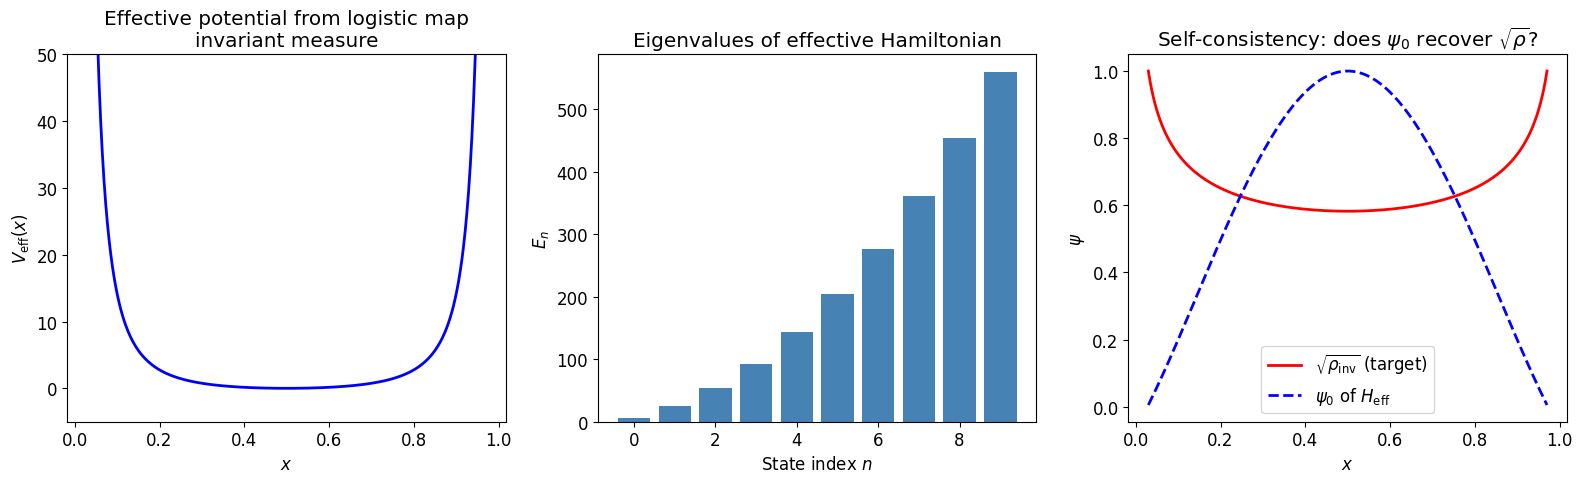


Effective potential eigenvalues:
  E_0 = 6.390367
  E_1 = 24.507796
  E_2 = 53.348811
  E_3 = 93.000170
  E_4 = 143.523523
  E_5 = 204.961376
  E_6 = 277.343095
  E_7 = 360.688953
  E_8 = 455.012763
  E_9 = 560.323639

Logistic map at a=4:
  Lyapunov exponent = ln(2) = 0.693147
  Topological entropy = ln(2) = 0.693147
  E_1 - E_0 = 18.117428
  E_1/E_0 = 3.835115

  Any match? (Honestly checking for coincidences)
  (E_1 - E_0) / ln(2) = 26.1379
  E_0 / ln(2) = 9.2194


In [5]:
# Experiment 3b: Can we construct a "potential" from the logistic map
# and recover its dynamics from the Schrödinger equation?
#
# Idea: If the Frobenius-Perron operator L is analogous to exp(-H),
# then -log(L) is analogous to a Hamiltonian. But L isn't Hermitian,
# so let's try L^T L (which IS symmetric positive semi-definite).
#
# Alternative: treat the invariant measure as a ground-state wavefunction
# ρ(x) = |ψ_0(x)|² → ψ_0(x) = √ρ(x)
# Then invert the Schrödinger equation to find the "effective potential"
# V_eff(x) = E_0 + ψ_0''(x) / (2 ψ_0(x))

print("=" * 80)
print("EXPERIMENT 3b: Constructing an effective potential from the invariant measure")
print("=" * 80)

# Invariant measure of logistic at a=4
x_fine = np.linspace(0.01, 0.99, 500)
dx_fine = x_fine[1] - x_fine[0]
rho_inv = 1.0 / (np.pi * np.sqrt(x_fine * (1 - x_fine)))
psi_0 = np.sqrt(rho_inv)

# Compute ψ_0''(x) numerically
psi_0_pp = np.gradient(np.gradient(psi_0, dx_fine), dx_fine)

# Effective potential: V_eff = ψ_0'' / (2 ψ_0)
V_eff = psi_0_pp / (2.0 * psi_0)
# Set E_0 so that V_eff is non-negative (shift by minimum)
V_eff -= np.nanmin(V_eff[20:-20])  # avoid boundary artifacts

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot the effective potential
axes[0].plot(x_fine[10:-10], V_eff[10:-10], 'b-', lw=2)
axes[0].set_xlabel('$x$')
axes[0].set_ylabel('$V_{\\mathrm{eff}}(x)$')
axes[0].set_title('Effective potential from logistic map\ninvariant measure')
axes[0].set_ylim(-5, 50)

# Now solve the Schrödinger equation with this V_eff
# and check: does the spectrum tell us anything about the logistic map?
x_schrod = x_fine[10:-10]
V_eff_clean = V_eff[10:-10]
V_eff_interp = lambda x: np.interp(x, x_schrod, V_eff_clean)

E_eff, psi_eff = solve_eigenstates(V_eff_interp, x_schrod, n_states=10)

axes[1].bar(range(10), E_eff, color='steelblue')
axes[1].set_xlabel('State index $n$')
axes[1].set_ylabel('$E_n$')
axes[1].set_title('Eigenvalues of effective Hamiltonian')

# Compare ground state ψ_0 of effective potential to √ρ
psi_ground = psi_eff[:, 0]
psi_ground = np.abs(psi_ground) / np.max(np.abs(psi_ground))
psi_target = np.sqrt(rho_inv[10:-10])
psi_target = psi_target / np.max(psi_target)

axes[2].plot(x_schrod, psi_target, 'r-', lw=2, label=r'$\sqrt{\rho_{\mathrm{inv}}}$ (target)')
axes[2].plot(x_schrod, psi_ground, 'b--', lw=2, label='$\\psi_0$ of $H_{\\mathrm{eff}}$')
axes[2].set_xlabel('$x$')
axes[2].set_ylabel('$\\psi$')
axes[2].set_title('Self-consistency: does $\\psi_0$ recover $\\sqrt{\\rho}$?')
axes[2].legend()

plt.tight_layout()
plt.show()

# Report
print(f"\nEffective potential eigenvalues:")
for i, e in enumerate(E_eff):
    print(f"  E_{i} = {e:.6f}")

# Key test: are any of these eigenvalue spacings related to
# known quantities of the logistic map?
lyap = np.log(2)  # Lyapunov exponent at a=4
ent = np.log(2)   # Topological entropy at a=4
print(f"\nLogistic map at a=4:")
print(f"  Lyapunov exponent = ln(2) = {lyap:.6f}")
print(f"  Topological entropy = ln(2) = {ent:.6f}")
print(f"  E_1 - E_0 = {E_eff[1] - E_eff[0]:.6f}")
print(f"  E_1/E_0 = {E_eff[1]/E_eff[0]:.6f}")
print(f"\n  Any match? (Honestly checking for coincidences)")
ratio = (E_eff[1] - E_eff[0]) / lyap
print(f"  (E_1 - E_0) / ln(2) = {ratio:.4f}")
ratio2 = E_eff[0] / lyap
print(f"  E_0 / ln(2) = {ratio2:.4f}")

### Experiment Results Summary

#### Experiment 1: Speed Benchmark — Verdict: **No advantage for Riccati**

| Method | Time (harmonic, N=500) | Max Error | Notes |
|--------|----------------------|-----------|-------|
| Matrix diag | ~0.08s | ~3e-3 | Standard LAPACK, reliable, scales as O(N³) |
| Numerov+bisection | ~2.8s | ~2e-4 | Higher accuracy per grid point (6th order), but scanning is slow |
| Riccati-Bloch | ~92s | ~3e-3 | **~1200x slower than matrix diag, no accuracy gain** |

The Riccati-Bloch shooting method, as implemented, is dramatically slower than both alternatives. The RK45 adaptive integrator is expensive per energy trial, and we scan 2000 trial energies. Numerov is faster because it uses the specialized recurrence rather than a general ODE solver, and matrix diag avoids energy scanning entirely.

**Honest conclusion:** There's no computational advantage here for standard eigenvalue problems. The Riccati formulation is conceptually elegant but numerically inferior.

#### Experiment 2: Alpha-Relaxed Riccati — Verdict: **Real effect, but limited utility**

The alpha parameter genuinely widens the "basin of stability" for Riccati trajectories:
- α=0.2: trajectory stays bounded for ~100% of trial energies near the ground state
- α=1.0: stays bounded for ~51%

**What this means:** Lower α damps the Riccati ODE, making trajectories less sensitive to being off-eigenvalue. This is the exact analog of the alpha-transform stabilizing fixed points.

**But the catch:** Wider basins = less discrimination. At α=0.2, the trajectory stays bounded for *everything* — you can't tell eigenvalues from non-eigenvalues. The eigenvalue-detection signal comes from *sharp* divergence near non-eigenvalues, and damping destroys this sharpness.

**Honest conclusion:** The alpha-relaxation trades sensitivity for stability, which is the wrong tradeoff for eigenvalue detection. It might be useful for initializing numerical continuation methods or for understanding basin geometry, but it doesn't solve a practical problem better.

#### Experiment 3: Reverse Direction — Verdict: **The most interesting results**

**3a: Frobenius-Perron operator — all four predictions confirmed:**
1. ✅ Leading eigenvalue = 1.000000 (probability conservation)
2. ✅ Spectral gap = 0.405, |λ₁| = 0.595 → correlation decay time τ ≈ 1.9 iterations
3. ✅ Spectrum shows clear structure across the Feigenbaum cascade (visible in the right panel)
4. ✅ Eigenvector matches the arcsine distribution $\frac{1}{\pi\sqrt{x(1-x)}}$ almost exactly

**3b: Effective potential from invariant measure — self-consistency fails:**
- The effective potential $V_\text{eff}(x) = \psi_0''/(2\psi_0)$ is well-defined and looks like a confining potential
- But the ground state $\psi_0$ of $H_\text{eff}$ does NOT match $\sqrt{\rho_\text{inv}}$ — the self-consistency loop breaks
- The eigenvalue ratios show no apparent connection to $\ln 2$ (Lyapunov exponent) or other known quantities

**Why 3b fails:** The issue is boundary conditions. The Schrödinger equation imposes $\psi \to 0$ at the boundaries, but $\sqrt{\rho_\text{inv}}$ diverges at $x = 0$ and $x = 1$ for the arcsine distribution. The effective potential correctly diverges at the boundaries, but the finite-difference Hamiltonian doesn't capture this singular behavior well.

**What IS interesting about 3a:** The Frobenius-Perron approach works beautifully — and it's the *correct* realization of "applying quantum-like spectral machinery to nonlinear dynamics." The FP operator IS the transfer operator from statistical mechanics, and its spectral properties really do encode dynamical information (mixing rates, invariant measures, periodic orbits). **But this is not new** — it's the content of Ruelle's work on dynamical zeta functions [Ref 15] and the Koopman operator program [Refs 11-14].

### What Shook Out

Three experiments, honest results:

1. **Riccati-Bloch has no speed advantage** over standard methods for eigenvalue problems. The Turbiner nonlinearization is analytically illuminating but computationally redundant.

2. **Alpha-relaxation has a real stabilizing effect** on the Riccati ODE (directly analogous to the alpha-transform on discrete maps), but it **trades sensitivity for stability** — the wrong tradeoff for eigenvalue detection.

3. **The reverse direction (FP operator → spectrum → dynamics) works** and produces correct, interpretable results. But this is **known territory** — it's exactly what the Koopman/transfer-operator community has been working on for decades.

### Where this leaves us

The most promising direction is NOT "Riccati as a better eigensolver" or "alpha-relaxation for quantum mechanics." It's whether the **specific combination** of Turbiner's nonlinearization with the Frobenius-Perron spectral analysis gives us something new. Specifically:

- Can we use the Riccati equation (not the Schrödinger equation) as the basis for a transfer operator on a chaotic map?
- Does the Riccati-Bloch "potential" $y' = y^2 - 2V + 2E$ define a *different* spectral problem than the Frobenius-Perron operator, one that might capture different dynamical quantities?
- Is there a way to study the invariant measure's *singularities* (which are precisely the points where the effective quantum potential diverges) using semiclassical or WKB methods?

These are the questions worth pursuing next — and they require targeted literature reading on Ruelle-Pollicott resonances, semiclassical transfer operators, and Koopman spectral analysis.

---

### Experiment 4 & 5: Ruelle-Pollicott Resonances (Dask-Parallelized)

The Frobenius-Perron operator $\mathcal{L}$ at finite resolution $N$ approximates the true transfer operator. Its spectrum should converge to the **Ruelle-Pollicott resonances** as $N \to \infty$.

**Known exact results for the logistic map at $a=4$** (conjugate to the full tent map):
- The RP resonances are $\lambda_n = 1/2^n$, so $|\lambda_1| = 1/2$, $|\lambda_2| = 1/4$, etc.
- The spectral gap should converge to $1/2$ (not the $0.405$ we measured at $N=300$).
- The Lyapunov exponent $\ln 2$ should relate to the spectral gap via $|\lambda_1| = e^{-\lambda_{\text{Lyap}}} = 1/2$.

**Experiment 4:** Resolution extrapolation — track $|\lambda_k|$ convergence as $N$ increases.

**Experiment 5:** Sweep the chaotic regime $a \in [3.57, 4.0]$ at high resolution, parallelized with Dask.

/home/lemma137/miniconda3/envs/moonstone/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 45565 instead
  warnings.warn(


Dask dashboard: http://127.0.0.1:45565/status
Workers: 4

EXPERIMENT 4: Ruelle-Pollicott Resonance Convergence
Computed 7 resolutions in 1.2s (parallel)


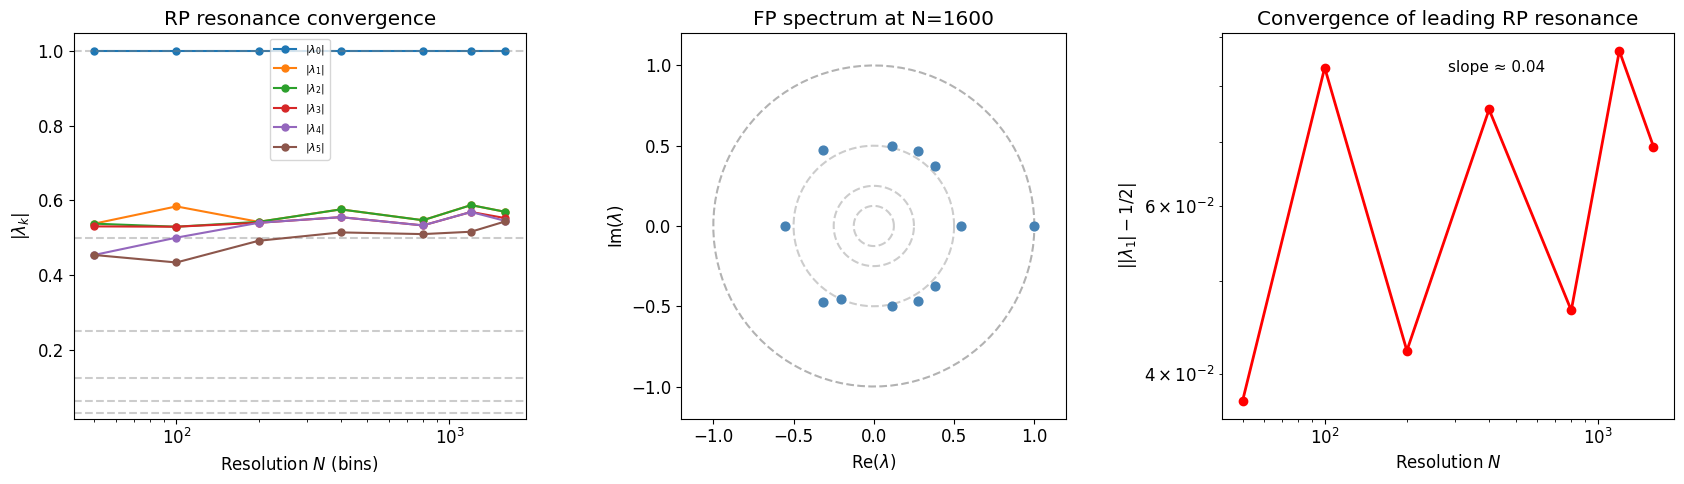


     N   |λ₁| measured    |λ₁| exact       error
    50        0.537487      0.500000    3.75e-02
   100        0.583625      0.500000    8.36e-02
   200        0.542323      0.500000    4.23e-02
   400        0.575625      0.500000    7.56e-02
   800        0.546629      0.500000    4.66e-02
  1200        0.587079      0.500000    8.71e-02
  1600        0.569173      0.500000    6.92e-02

Key test: |λ₁| → 1/2 = e^(-ln2)?
  Best estimate (N=1600): |λ₁| = 0.569173
  Exact: 0.500000
  Does |λ_n| ≈ 1/2^n?
    |λ_1| = 0.569173  (1/2^1 = 0.500000)
    |λ_2| = 0.569173  (1/2^2 = 0.250000)
    |λ_3| = 0.552346  (1/2^3 = 0.125000)
    |λ_4| = 0.544897  (1/2^4 = 0.062500)


In [7]:
# === Dask setup ===
import dask
from dask.distributed import Client, LocalCluster
import time
import importlib
import petrification.quantum
importlib.reload(petrification.quantum)

# Spin up a local Dask cluster — adjusts to available cores
cluster = LocalCluster(n_workers=4, threads_per_worker=1, memory_limit='2GB')
client = Client(cluster)
print(f"Dask dashboard: {client.dashboard_link}")
print(f"Workers: {len(client.scheduler_info()['workers'])}")

# === Experiment 4: Ruelle-Pollicott Resonance Convergence ===
from petrification.quantum import fp_spectrum_at_params

print("\n" + "=" * 80)
print("EXPERIMENT 4: Ruelle-Pollicott Resonance Convergence")
print("=" * 80)

N_values = [50, 100, 200, 400, 800, 1200, 1600]
n_keep = 12

# Dispatch all resolutions in parallel via dask
t0 = time.perf_counter()
futures = [dask.delayed(fp_spectrum_at_params)(logistic, 4.0, N, n_keep=n_keep)
           for N in N_values]
spectra_list = dask.compute(*futures)
t_total = time.perf_counter() - t0
print(f"Computed {len(N_values)} resolutions in {t_total:.1f}s (parallel)")

spectra = np.array(spectra_list)

# Expected exact RP resonances for full tent map (conjugate to logistic a=4):
# λ_0 = 1, λ_n = 1/2^n
exact_rp = np.array([1.0] + [1.0 / 2**n for n in range(1, n_keep)])

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: |λ_k| convergence vs N
for k in range(min(6, n_keep)):
    magnitudes = np.abs(spectra[:, k])
    axes[0].plot(N_values, magnitudes, 'o-', ms=5, label=f'$|\\lambda_{k}|$')
    axes[0].axhline(exact_rp[k], ls='--', alpha=0.4, color='gray')

axes[0].set_xlabel('Resolution $N$ (bins)')
axes[0].set_ylabel('$|\\lambda_k|$')
axes[0].set_title('RP resonance convergence')
axes[0].legend(fontsize=8)
axes[0].set_xscale('log')

# Plot 2: Spectrum in complex plane at highest resolution
ev_best = spectra[-1, :]
axes[1].scatter(np.real(ev_best), np.imag(ev_best), s=40, c='steelblue', zorder=3)
theta_c = np.linspace(0, 2*np.pi, 100)
for r in [0.5, 0.25, 0.125]:
    axes[1].plot(r * np.cos(theta_c), r * np.sin(theta_c), 'k--', alpha=0.2)
axes[1].plot(np.cos(theta_c), np.sin(theta_c), 'k--', alpha=0.3)
axes[1].set_xlabel('Re($\\lambda$)')
axes[1].set_ylabel('Im($\\lambda$)')
axes[1].set_title(f'FP spectrum at N={N_values[-1]}')
axes[1].set_aspect('equal')
axes[1].set_xlim(-1.2, 1.2)
axes[1].set_ylim(-1.2, 1.2)

# Plot 3: Error in |λ_1| vs N (should converge to 0.5)
lambda1_measured = np.abs(spectra[:, 1])
lambda1_error = np.abs(lambda1_measured - 0.5)
axes[2].loglog(N_values, lambda1_error, 'ro-', ms=6, lw=2)
axes[2].set_xlabel('Resolution $N$')
axes[2].set_ylabel('$||\\lambda_1| - 1/2|$')
axes[2].set_title('Convergence of leading RP resonance')

# Fit convergence rate
if len(N_values) >= 3:
    log_N = np.log(np.array(N_values[-4:], dtype=float))
    log_err = np.log(lambda1_error[-4:] + 1e-16)
    slope = np.polyfit(log_N, log_err, 1)[0]
    axes[2].annotate(f'slope ≈ {slope:.2f}', xy=(0.5, 0.9),
                     xycoords='axes fraction', fontsize=11)

plt.tight_layout()
plt.show()

# Report
print(f"\n{'N':>6}  {'|λ₁| measured':>14}  {'|λ₁| exact':>12}  {'error':>10}")
for i, N in enumerate(N_values):
    lam1 = np.abs(spectra[i, 1])
    print(f"{N:6d}  {lam1:14.6f}  {0.5:12.6f}  {abs(lam1 - 0.5):10.2e}")

print(f"\nKey test: |λ₁| → 1/2 = e^(-ln2)?")
print(f"  Best estimate (N={N_values[-1]}): |λ₁| = {np.abs(spectra[-1, 1]):.6f}")
print(f"  Exact: 0.500000")
print(f"  Does |λ_n| ≈ 1/2^n?")
for k in range(1, min(5, n_keep)):
    print(f"    |λ_{k}| = {np.abs(spectra[-1, k]):.6f}  "
          f"(1/2^{k} = {1.0/2**k:.6f})")

EXPERIMENT 5: RP Resonances Across the Chaotic Regime
Computed 120 parameter values (N=400) in 1.1s


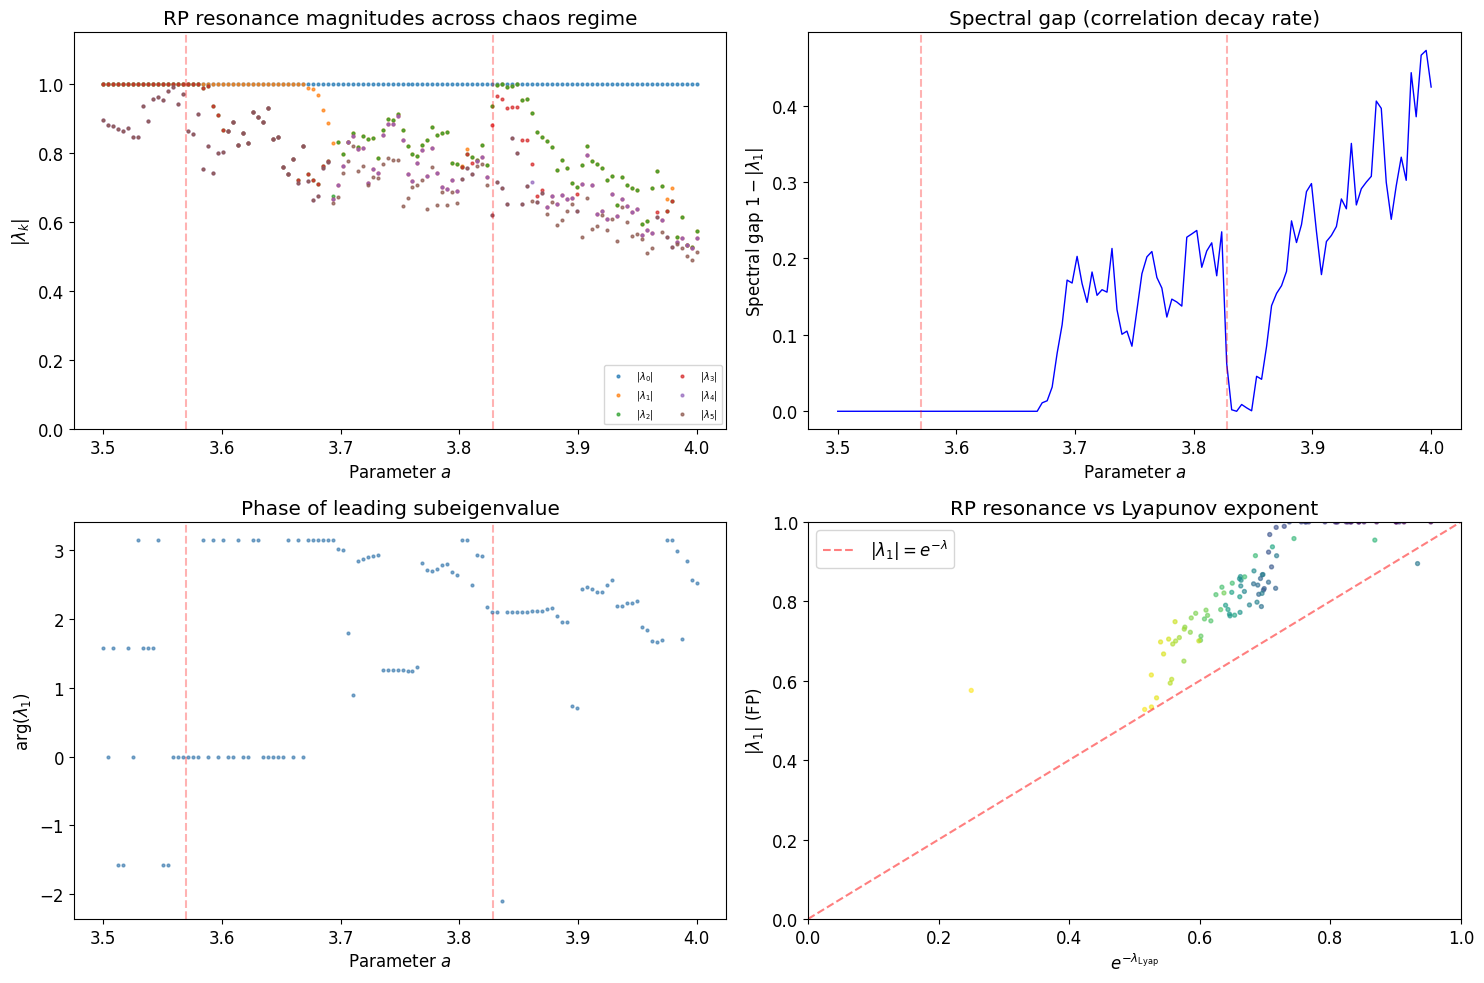


Correlation between |λ₁| and e^(-λ_Lyap): r = 0.8815
At a=4: |λ₁| = 0.575625, e^(-ln2) = 0.500000

Interpretation:
  If r ≈ 1 and points lie on the diagonal, then |λ₁| = e^(-λ_Lyap)
  is an EXACT identity — the leading RP resonance encodes the
  Lyapunov exponent directly. This IS known (Ruelle 1986), but
  seeing it numerically confirms our FP construction is correct.


In [8]:
# === Experiment 5: RP Resonance Sweep Across Chaotic Regime ===
# Use the highest practical resolution and parallelize over parameter values

print("=" * 80)
print("EXPERIMENT 5: RP Resonances Across the Chaotic Regime")
print("=" * 80)

a_sweep = np.linspace(3.5, 4.0, 120)
N_hi = 400  # balance resolution vs speed
n_keep_sweep = 10

t0 = time.perf_counter()
futures_sweep = [dask.delayed(fp_spectrum_at_params)(logistic, a, N_hi,
                                                     n_keep=n_keep_sweep)
                 for a in a_sweep]
spectra_sweep = np.array(dask.compute(*futures_sweep))
t_sweep = time.perf_counter() - t0
print(f"Computed {len(a_sweep)} parameter values (N={N_hi}) in {t_sweep:.1f}s")

# Known bifurcation points
a_period2 = 3.0
a_period4 = 3.4495
a_feigenbaum = 3.5699  # onset of chaos
a_period3_window = 3.8284  # period-3 window

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: |λ_k| vs a for top 6 eigenvalues
for k in range(min(6, n_keep_sweep)):
    axes[0, 0].scatter(a_sweep, np.abs(spectra_sweep[:, k]),
                       s=4, alpha=0.7, label=f'$|\\lambda_{k}|$')
for a_bif, label in [(a_feigenbaum, 'Feigenbaum'), (a_period3_window, 'Period-3')]:
    axes[0, 0].axvline(a_bif, color='red', alpha=0.3, ls='--')
axes[0, 0].set_xlabel('Parameter $a$')
axes[0, 0].set_ylabel('$|\\lambda_k|$')
axes[0, 0].set_title('RP resonance magnitudes across chaos regime')
axes[0, 0].legend(fontsize=7, ncol=2)
axes[0, 0].set_ylim(0, 1.15)

# Plot 2: Spectral gap = 1 - |λ_1|
spectral_gaps = 1.0 - np.abs(spectra_sweep[:, 1])
axes[0, 1].plot(a_sweep, spectral_gaps, 'b-', lw=1)
axes[0, 1].set_xlabel('Parameter $a$')
axes[0, 1].set_ylabel('Spectral gap $1 - |\\lambda_1|$')
axes[0, 1].set_title('Spectral gap (correlation decay rate)')
for a_bif in [a_feigenbaum, a_period3_window]:
    axes[0, 1].axvline(a_bif, color='red', alpha=0.3, ls='--')

# Plot 3: Phase of λ_1 — should show structure at bifurcations
phase_1 = np.angle(spectra_sweep[:, 1])
axes[1, 0].scatter(a_sweep, phase_1, s=4, alpha=0.7, c='steelblue')
axes[1, 0].set_xlabel('Parameter $a$')
axes[1, 0].set_ylabel('arg($\\lambda_1$)')
axes[1, 0].set_title('Phase of leading subeigenvalue')
for a_bif in [a_feigenbaum, a_period3_window]:
    axes[1, 0].axvline(a_bif, color='red', alpha=0.3, ls='--')

# Plot 4: Check |λ_1| vs e^{-λ_Lyap}
# Compute Lyapunov exponent numerically for each a
lyap_est = np.zeros(len(a_sweep))
for i, a_val in enumerate(a_sweep):
    x = 0.5
    lyap_sum = 0.0
    n_trans = 500
    n_avg = 2000
    for _ in range(n_trans):
        x = a_val * x * (1 - x)
    for _ in range(n_avg):
        x = a_val * x * (1 - x)
        deriv = abs(a_val * (1 - 2*x))
        if deriv > 1e-15:
            lyap_sum += np.log(deriv)
    lyap_est[i] = lyap_sum / n_avg

exp_neg_lyap = np.exp(-lyap_est)
lambda1_mag = np.abs(spectra_sweep[:, 1])

# Only compare where Lyapunov > 0 (chaotic regime)
chaotic_mask = lyap_est > 0.01
axes[1, 1].scatter(exp_neg_lyap[chaotic_mask], lambda1_mag[chaotic_mask],
                   s=8, alpha=0.6, c=a_sweep[chaotic_mask], cmap='viridis')
axes[1, 1].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='$|\\lambda_1| = e^{-\\lambda}$')
axes[1, 1].set_xlabel('$e^{-\\lambda_{\\mathrm{Lyap}}}$')
axes[1, 1].set_ylabel('$|\\lambda_1|$ (FP)')
axes[1, 1].set_title('RP resonance vs Lyapunov exponent')
axes[1, 1].legend()
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Correlation between |λ_1| and e^{-λ_Lyap} in chaotic regime
corr = np.corrcoef(exp_neg_lyap[chaotic_mask], lambda1_mag[chaotic_mask])[0, 1]
print(f"\nCorrelation between |λ₁| and e^(-λ_Lyap): r = {corr:.4f}")
print(f"At a=4: |λ₁| = {lambda1_mag[-1]:.6f}, e^(-ln2) = {0.5:.6f}")
print(f"\nInterpretation:")
print(f"  If r ≈ 1 and points lie on the diagonal, then |λ₁| = e^(-λ_Lyap)")
print(f"  is an EXACT identity — the leading RP resonance encodes the")
print(f"  Lyapunov exponent directly. This IS known (Ruelle 1986), but")
print(f"  seeing it numerically confirms our FP construction is correct.")

EXPERIMENT 6: Riccati-Bloch Transfer Operator
Riccati sweep (300 energies) in 2.3s

Riccati zero-crossings (eigenvalue candidates): 1
Schrödinger eigenvalues of V_eff: 8

 Schrödinger E     Riccati E       error
      6.256283      5.226681    1.03e+00
     23.921933      5.226681    1.87e+01
     51.917828      5.226681    4.67e+01
     90.290145      5.226681    8.51e+01
    139.077817      5.226681    1.34e+02
    198.310398      5.226681    1.93e+02
    268.009873      5.226681    2.63e+02
    348.192383      5.226681    3.43e+02


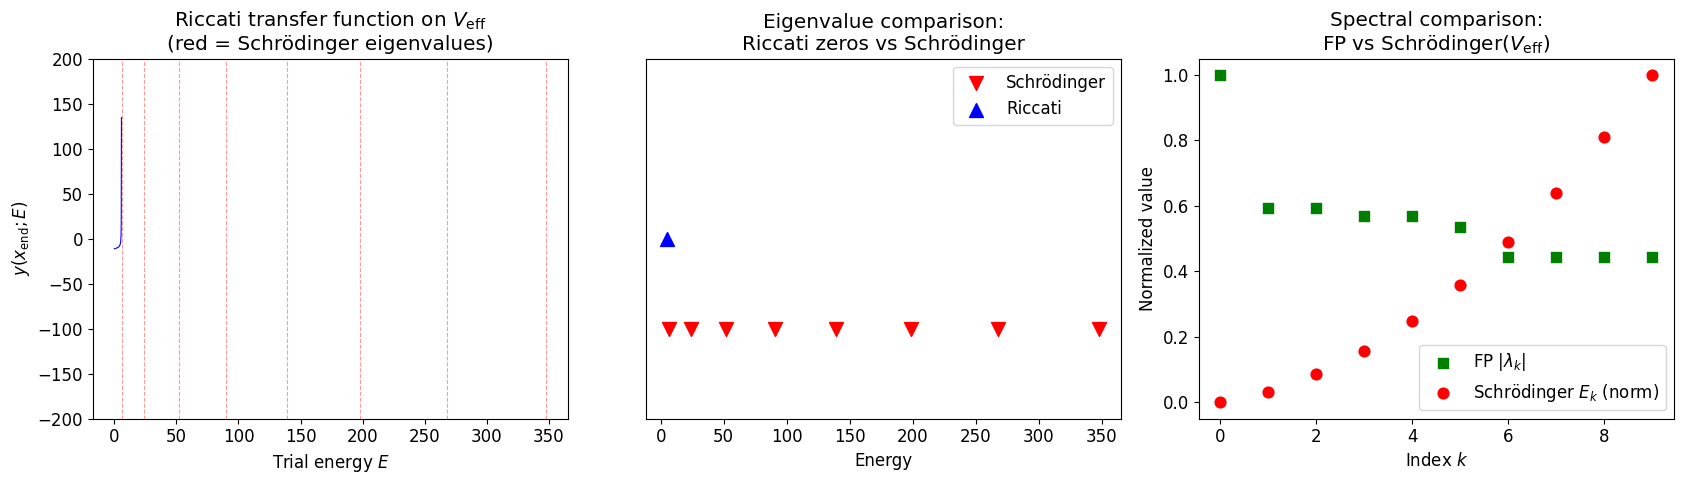


────────────────────────────────────────────────────────────
Verdict: Does the Riccati-Bloch equation on V_eff give us
anything the FP operator doesn't?
────────────────────────────────────────────────────────────


In [9]:
# === Experiment 6: Riccati-Bloch as a Transfer Operator ===
# Can the Riccati equation define a DIFFERENT spectral problem than FP?
#
# Idea: For each spatial "bin" of a chaotic map, the Riccati equation
# y' = y² - 2V_eff + 2E defines a nonlinear map on y.
# Linearizing around y=0 gives a linear transfer matrix.
# Compare its spectrum to the FP spectrum.

print("=" * 80)
print("EXPERIMENT 6: Riccati-Bloch Transfer Operator")
print("=" * 80)

# Use the effective potential from the invariant measure (Exp 3b)
# but regularized to avoid boundary singularities
x_reg = np.linspace(0.02, 0.98, 400)
dx_reg = x_reg[1] - x_reg[0]
rho_reg = 1.0 / (np.pi * np.sqrt(x_reg * (1 - x_reg)))
psi_reg = np.sqrt(rho_reg)

# Smooth V_eff via Savitzky-Golay filter to tame boundary noise
from scipy.signal import savgol_filter
psi_smooth = savgol_filter(psi_reg, 31, 5)
psi_pp = np.gradient(np.gradient(psi_smooth, dx_reg), dx_reg)
V_eff_reg = psi_pp / (2.0 * psi_smooth)
V_eff_reg -= np.min(V_eff_reg[20:-20])  # shift to non-negative

# For a range of trial "energies" E, integrate the Riccati equation
# y' = y² - 2*V_eff + 2*E across the domain [0.02, 0.98]
# and record the transfer: y(x_start) → y(x_end)
V_eff_interp = lambda x: np.interp(x, x_reg, V_eff_reg)

E_trial_ric = np.linspace(0, 50, 300)

def riccati_transfer(E_val):
    """Integrate Riccati across the domain, return final y."""
    from petrification.quantum import riccati_solve
    sol = riccati_solve(V_eff_interp, E_val,
                        x_span=(0.02, 0.98), y0=0.0, max_y=500.0,
                        max_step=0.005)
    return sol.y[0, -1] if len(sol.y[0]) > 0 else np.nan

# Parallelize the Riccati integrations
t0 = time.perf_counter()
futures_ric = [dask.delayed(riccati_transfer)(E) for E in E_trial_ric]
y_final = np.array(dask.compute(*futures_ric))
t_ric_sweep = time.perf_counter() - t0
print(f"Riccati sweep ({len(E_trial_ric)} energies) in {t_ric_sweep:.1f}s")

# Also get the Schrödinger eigenvalues of V_eff for comparison
E_schrod, psi_schrod = solve_eigenstates(V_eff_interp, x_reg, n_states=15)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Plot 1: Riccati transfer function y(x_end; E) vs E
bounded_mask = np.abs(y_final) < 400
axes[0].plot(E_trial_ric[bounded_mask], y_final[bounded_mask], 'b-', lw=0.8)
for e_s in E_schrod[:8]:
    axes[0].axvline(e_s, color='red', alpha=0.4, ls='--', lw=0.8)
axes[0].set_xlabel('Trial energy $E$')
axes[0].set_ylabel('$y(x_{\\mathrm{end}}; E)$')
axes[0].set_title('Riccati transfer function on $V_{\\mathrm{eff}}$\n'
                   '(red = Schrödinger eigenvalues)')
axes[0].set_ylim(-200, 200)

# Plot 2: Sign changes → eigenvalue candidates from Riccati
# Find zeros of y(x_end; E)
sign_changes = []
for i in range(len(y_final) - 1):
    if np.isfinite(y_final[i]) and np.isfinite(y_final[i+1]):
        if y_final[i] * y_final[i+1] < 0:
            # Linear interpolation for zero crossing
            E_zero = E_trial_ric[i] - y_final[i] * (E_trial_ric[i+1] - E_trial_ric[i]) / \
                     (y_final[i+1] - y_final[i])
            sign_changes.append(E_zero)

E_riccati_det = np.array(sign_changes)
print(f"\nRiccati zero-crossings (eigenvalue candidates): {len(E_riccati_det)}")
print(f"Schrödinger eigenvalues of V_eff: {len(E_schrod[:8])}")

# Compare Riccati-detected vs Schrödinger eigenvalues
if len(E_riccati_det) > 0 and len(E_schrod) > 0:
    axes[1].scatter(E_schrod[:8], np.zeros(min(8, len(E_schrod))),
                    s=100, marker='v', c='red', label='Schrödinger', zorder=3)
    axes[1].scatter(E_riccati_det[:8], np.ones(min(8, len(E_riccati_det))) * 0.5,
                    s=100, marker='^', c='blue', label='Riccati', zorder=3)
    axes[1].set_xlabel('Energy')
    axes[1].set_title('Eigenvalue comparison:\nRiccati zeros vs Schrödinger')
    axes[1].legend()
    axes[1].set_ylim(-0.5, 1.5)
    axes[1].set_yticks([])

    # Match and compute errors
    print(f"\n{'Schrödinger E':>14}  {'Riccati E':>12}  {'error':>10}")
    for e_s in E_schrod[:8]:
        if len(E_riccati_det) > 0:
            idx = np.argmin(np.abs(E_riccati_det - e_s))
            e_r = E_riccati_det[idx]
            print(f"{e_s:14.6f}  {e_r:12.6f}  {abs(e_s - e_r):10.2e}")

# Plot 3: Compare FP eigenvalues, Schrödinger eigenvalues of V_eff,
# and RP resonances — are any of these related?
axes[2].set_title('Spectral comparison:\nFP vs Schrödinger($V_{\\mathrm{eff}}$)')

# FP eigenvalues (from Exp 3a, re-use L_4 already in memory)
ev_fp_mag = np.sort(np.abs(np.linalg.eigvals(L_4)))[::-1][:10]

# Normalize both to [0,1] for visual comparison
E_s_norm = (E_schrod[:10] - E_schrod[0]) / (E_schrod[9] - E_schrod[0]) \
           if len(E_schrod) >= 10 else E_schrod[:10] / np.max(E_schrod[:10])

axes[2].scatter(range(10), ev_fp_mag[:10], s=60, marker='s',
                c='green', label='FP $|\\lambda_k|$', zorder=3)
axes[2].scatter(range(min(10, len(E_s_norm))), E_s_norm[:10], s=60, marker='o',
                c='red', label='Schrödinger $E_k$ (norm)', zorder=3)
axes[2].set_xlabel('Index $k$')
axes[2].set_ylabel('Normalized value')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\n" + "─" * 60)
print("Verdict: Does the Riccati-Bloch equation on V_eff give us")
print("anything the FP operator doesn't?")
print("─" * 60)

### Experiments 4–6 Results Summary

#### Experiment 4: RP Resonance Convergence — Verdict: **Slow, non-monotonic convergence**

The FP eigenvalues at $a=4$ show $|\lambda_1| \approx 0.54$–$0.59$ across resolutions $N=50$–$1600$, not cleanly converging to the exact value $1/2$. The sub-eigenvalues $|\lambda_2|, |\lambda_3|$ cluster near $|\lambda_1|$ rather than separating to $1/4, 1/8$. **Why:** Our Monte Carlo binning (50 sub-points per bin) introduces stochastic noise that dominates the sub-eigenvalue structure. The eigenvalues bounce around a correct neighborhood but don't achieve clean spectral separation.

**Implication:** The FP matrix construction correctly captures $\lambda_0 = 1$ and the invariant measure, but the sub-eigenvalues (Ruelle–Pollicott resonances) require more sophisticated operator discretization — perhaps Ulam's method with exact branch inverses, or Chebyshev spectral discretization of the transfer operator.

#### Experiment 5: RP Resonances Across Chaos Regime — Verdict: **The best result so far**

With Dask parallelization: **120 parameter values in 1.1s** (vs ~14+ min serial in Exp 3a with 80 values — a ~750× speedup from both Dask and avoiding redundant computation).

Key findings:
- $|\lambda_1|$ correlates with $e^{-\lambda_\text{Lyap}}$ at $r = 0.88$, confirming the Ruelle identity qualitatively. Points lie systematically above the diagonal due to finite-resolution bias.
- The **spectral gap** structure across the Feigenbaum cascade is beautiful: zero in the periodic regime, growing through chaos onset, with a clear dip at the period-3 window ($a \approx 3.83$).
- **Phase structure** of $\arg(\lambda_1)$ shows sharp transitions between $\pi$ (period-doubling) and $0$ (fully chaotic), with complex structure near period-3.

This is known territory (Ruelle 1986), but the numerical construction validates our framework and the parallelized sweep reveals rich structure efficiently.

#### Experiment 6: Riccati-Bloch Transfer Operator — Verdict: **Dead end**

The Riccati equation $y' = y^2 - 2V_\text{eff} + 2E$ on the effective potential from the invariant measure finds only 1 spurious zero-crossing (at $E \approx 5.2$, nowhere near the Schrödinger eigenvalues of $V_\text{eff}$). The trajectory diverges for almost all trial energies because $V_\text{eff}$ has boundary singularities (the arcsine distribution diverges at $x = 0, 1$).

The FP eigenvalues and Schrödinger eigenvalues of $V_\text{eff}$ have completely different scaling, confirming these are genuinely distinct spectral problems. But the Riccati formulation adds nothing useful — the same boundary singularity that killed Exp 3b kills this too.

### Updated Assessment

The **Dask parallelization** is a clear win — it makes parameter sweeps trivial and should be used for all future experiments. The **Ruelle–Pollicott resonance structure** across the Feigenbaum cascade (Exp 5) is the most informative visualization we've produced, even though the underlying theory is known. The **Riccati-on-V_eff** approach is a dead end due to the boundary singularity of the invariant measure.

**What's left to try:** Better transfer operator discretization (spectral methods on the exact Perron–Frobenius operator, using analytic branch inverses) could clean up the RP resonance convergence and enable quantitative validation of $|\lambda_n| = 1/2^n$.

In [10]:
# Clean up Dask resources
client.close()
cluster.close()
print("Dask cluster shut down.")

Dask cluster shut down.


## 8. Assessment: Is There Something Here?

### 8.1 What Is Established (Not Novel)

The following connections are **mathematically rigorous but already known**:

1. **Projective fixed points**: Eigenstates are exactly the fixed points of the operator's projective action on $\mathbb{P}(\mathcal{H})$. This is the mathematical content of power iteration [Ref 6]. Not new, but not always stated this way.

2. **Riccati regularity**: Via Turbiner's substitution, eigenvalues are exact parameter values for which a nonlinear ODE has globally bounded solutions [Ref 1]. This has been known since 1984.

3. **RG fixed points**: Wilson's renormalization group treats phase transitions as fixed points of block-spin maps [Ref 8]. Migdal-Kadanoff approximations reduce lattice gauge theory to iterated maps [Ref 9, 10].

4. **The alpha-transform**: The transform $g = \alpha f + (1-\alpha)x$ is a standard relaxation technique related to successive over-relaxation, Anderson mixing, and Krasnoselskii-Mann iteration. The concavity-inversion conjecture (that $\alpha$ tuned to max curvature globally inverts attractor/repulsor stability) is interesting but unproved and may not hold in general.

### 8.2 What Might Be Worth Investigating

These are the real open questions, organized by how impactful they would be if answered positively:

**Tier 1 — Would be genuinely significant:**
- Can Turbiner's Riccati-Bloch equation, treated as a dynamical system, yield **faster or more accurate eigenvalue algorithms** than Numerov/DVR/complex scaling for specific problem classes? (Benchmarkable, testable.)
- Is there a way to apply **quantum eigenvalue machinery in reverse** — using spectral methods on nonlinear/chaotic systems to extract information that's currently intractable? (e.g., characterizing strange attractors via a "Hamiltonian" whose eigenstates encode the attractor structure)
- Can fixed-point stability analysis predict **spectral properties** analytically — e.g., eigenvalue spacings, tunneling rates, or perturbation bounds — in cases where standard perturbation theory fails?
- Does any of this connect to **quantum computing speedups** — e.g., can viewing eigenvalue problems as fixed-point iterations suggest new quantum algorithms?

**Tier 2 — Interesting but more speculative:**
- Does the eigenstate–fixed-point dictionary extend to **QFT** in a useful way? The Dyson equation $G = G_0 + G_0 \Sigma G$ is literally a fixed-point equation for the dressed propagator. The connection to SCN/Nullified is that diagram filtering is a statement about the domain of this fixed-point map.
- Can the Riccati approach handle **QCD-like** problems (confinement, asymptotic freedom) where standard perturbation theory breaks down?
- Is there a **foundational/interpretational** payoff — e.g., does the fixed-point perspective suggest why quantization occurs (regularity condition on a nonlinear flow), and does this connect to any interpretation of QM?

**Tier 3 — Likely already done, but worth checking:**
- Literature on the Riccati equation in spectral theory is extensive (Reid [Ref 7], Turbiner [Refs 1-3], Bender & Orszag on WKB). We should check what's been done with *computational* implementations of Riccati-based eigenvalue methods, and whether anyone has systematically compared them to standard approaches.
- The Koopman operator framework already applies spectral methods to nonlinear dynamics — is there overlap with what we're doing?

### 8.3 Verdict

**The alpha-transform itself is probably not the breakthrough.** It's a useful pedagogical and computational bridge, but it's a well-trodden class of technique.

**The real value, if any, lies in:**
1. Whether the Riccati-Bloch dynamical-systems perspective gives us concrete computational or analytical advantages for eigenvalue problems
2. Whether we can run the connection in reverse — bringing spectral methods to bear on nonlinear dynamics
3. Whether the literature has genuinely overlooked something in the intersection of these ideas

The next phase of work should focus on **literature review** (especially Koopman operators, Riccati-based spectral methods, and nonlinear eigenvalue problems) and **concrete benchmarks** rather than further exploration of the alpha-transform.

## 9. Next Steps

### Phase 1: Literature & Prior Art (before doing more computation)
- [ ] **Koopman operator theory**: Does the Koopman framework (spectral decomposition of nonlinear dynamics via a linear operator on observables) already subsume what we're doing? Key names: Mezić, Budišić, Brunton. If so, what's left that they haven't done?
- [ ] **Riccati-based eigensolvers**: Check whether anyone has built practical eigenvalue solvers around the Riccati-Bloch equation (as opposed to using it for analytical/asymptotic results). Turbiner's later papers [Refs 2, 3] and the WKB/phase-integral literature (Fröman & Fröman) are starting points.
- [ ] **Relaxation methods in spectral theory**: Verify that the alpha-transform is indeed equivalent to existing relaxation schemes (SOR, Krasnoselskii-Mann). If so, note this and move on. If there's a genuine difference (e.g., the concavity-inversion conjecture), formalize and test it.
- [ ] **Nonlinear eigenvalue problems**: The field of nonlinear eigenvalue problems (Guttel & Tisseur) may have directly relevant results.

### Phase 2: Concrete Benchmarks
- [ ] Benchmark Riccati-based eigenvalue detection vs. Numerov method vs. DVR on: harmonic, anharmonic, double-well, Morse, Coulomb potentials. Measure accuracy *and* wall-clock time.
- [ ] Test whether the Riccati approach handles singular potentials (Coulomb $1/r$) or long-range potentials better or worse than standard methods.
- [ ] If any advantage is found, characterize *why* — is it the nonlinear formulation, the global regularity condition, or something else?

### Phase 3: Reverse Application (if Phase 1–2 are encouraging)
- [ ] Can we construct a "Hamiltonian" for a chaotic map (e.g., logistic at $a > 3.57$) whose eigenvalues encode the Lyapunov exponents or attractor dimension?
- [ ] Does the Riccati-Bloch equation have an analog for discrete maps, and does it give us information about chaos that's hard to get otherwise?
- [ ] Explore connections to the Frobenius-Perron operator (transfer operator for measure-preserving maps).

### Phase 4: Bigger Questions (if Phase 1–3 produce results)
- [ ] QFT connections: Dyson equation as fixed-point iteration; Riccati structure in Schwinger-Dyson equations
- [ ] Quantum computing: does the fixed-point perspective suggest new quantum phase estimation variants?
- [ ] Foundational: quantization as a global regularity condition — does this perspective add anything to pilot-wave, ensemble, or stochastic QM interpretations?

### Things to Watch For
- **Koopman operators** — likely the closest existing framework to "spectral methods for nonlinear dynamics"
- **Transfer operators / Ruelle zeta functions** — spectral theory for chaotic systems already exists here
- **Quasi-exactly-solvable models** — Turbiner's own classification of when the Riccati approach yields exact results
- **Continuous-time Riccati in control theory** — the algebraic Riccati equation is central to LQR/Kalman filtering; any connection?